# Orbit Propagator — Gannon Geomagnetic Storm (May 2024)
### High-precision ECI propagation with JB2008 atmospheric drag

##Install necessary dependencies

In [1]:
# !pip install -q pandas numpy matplotlib plotly scipy astropy spiceypy cartopy sgp4 scikit-learn

##Import modules

In [2]:
import ast, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe
import plotly.graph_objects as go

from datetime import datetime, timedelta, timezone
from scipy.constants import c
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d, CubicSpline
from scipy.spatial.transform import Rotation

from astropy.coordinates import TEME, GCRS, CartesianRepresentation, CartesianDifferential
from astropy.time import Time
import astropy.units as u

import spiceypy as spice

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sgp4.api import Satrec, jday
from sklearn.linear_model import Ridge

##Ephemeris Generation

###1. Sun ephemeris

In [3]:
spice.furnsh('naif0012.tls')
spice.furnsh('de440s.bsp')
spice.furnsh('pck00010.tpc')
spice.furnsh('earth_fixed.tf')
spice.furnsh('earth_latest_high_prec.bpc')

start_time = "2024-05-09T00:00:00"
et_start   = spice.str2et(start_time)
N_EPHEM    = 4 * 24 * 60 * 60
times      = et_start + np.arange(N_EPHEM)

def get_state_vectors(body, observer):
    states = np.zeros((len(times), 6))
    for i, et in enumerate(times):
        state, _ = spice.spkezr(body, et, "J2000", "NONE", observer)
        states[i] = state
    return states

np.savetxt("coordi.txt", get_state_vectors("SUN", "EARTH"), delimiter=",", fmt="%.10f")
print("Saved coordi.txt")

Saved coordi.txt


###2. Sun Ephemeris Sanity Check

In [4]:
def preview_and_check_6d(file_path, name):
    data = np.loadtxt(file_path, delimiter=",")
    assert data.ndim == 2 and data.shape[1] == 6
    pos_norms = np.linalg.norm(data[:, :3], axis=1)
    vel_norms = np.linalg.norm(data[:, 3:], axis=1)
    print(f"{name}: shape={data.shape}, "
          f"|r| mean={pos_norms.mean():.3e} km, "
          f"|v| mean={vel_norms.mean():.3e} km/s")
    assert not np.isnan(data).any()
    return data

sun_states = preview_and_check_6d("coordi.txt", "Sun geocentric")

Sun geocentric: shape=(345600, 6), |r| mean=1.511e+08 km, |v| mean=2.950e+01 km/s


###3. Earth Rotation Matrix

In [5]:
def get_earth_rotation_ephem(times):
    data = np.zeros((len(times), 18))
    for i, et in enumerate(times):
        R_eci2ecef   = spice.pxform('J2000', 'ITRF93', et)
        M            = spice.sxform('ITRF93', 'J2000', et)
        dRdt         = M[3:6, 0:3]
        data[i, :9]  = R_eci2ecef.flatten()
        data[i, 9:]  = dRdt.flatten()
    return data

np.savetxt("earth_rotation_ephem.txt",
           get_earth_rotation_ephem(times), delimiter=",", fmt="%.15e")
print("Saved earth_rotation_ephem.txt")

Saved earth_rotation_ephem.txt


###4. Earth Rotation Sanity Check

In [6]:
def preview_and_check_earth_rotation(file_path):
    data  = np.loadtxt(file_path, delimiter=",")
    step  = max(1, len(data) // 100)
    ortho = [np.linalg.norm(data[i, :9].reshape(3,3) @ data[i, :9].reshape(3,3).T - np.eye(3))
             for i in range(0, len(data), step)]
    omega_E  = 7.2921150e-5
    dRdt_n   = np.linalg.norm(data[:, 9:].reshape(-1, 3, 3), axis=(1, 2))
    print(f"Orthogonality max error : {max(ortho):.2e}  (< 1e-10 ✓)")
    print(f"|dRdt| mean : {dRdt_n.mean():.6e}  (expect {np.sqrt(2)*omega_E:.6e})")
    return data

rot_ephem = preview_and_check_earth_rotation("earth_rotation_ephem.txt")

Orthogonality max error : 6.78e-16  (< 1e-10 ✓)
|dRdt| mean : 1.031261e-04  (expect 1.031261e-04)


##Parameters

###1. Physical Constants and Sun Interpolators

In [7]:
mu_jgm2  = 398600.4415
Re_jgm2  = 6378.1363
Rs       = 696340.0
AU       = 149597870.7
TSI      = 1362.0
c_light  = c

m        = 260 #kg

area_srp = 5.5
area_drag = 9.0
Cr       = 1.35
C_d      = 2.2

print(f"  B* (ballistic coeff) : {m/(C_d * area_drag):.2f} kg/m²")
print(f"  Cr                   : {Cr}")

with open('GGM03C.txt', 'r') as f:
    for line in f:
        parts = line.split()
        if int(parts[0]) == 2 and int(parts[1]) == 0:
            C20_bar = float(parts[2]); break

mu = mu_jgm2
Re = Re_jgm2
J2 = -np.sqrt(5.0) * C20_bar

EPOCH0 = datetime(2024, 5, 9, 0, 0, 0)
DATE0  = "2024-05-09T00:00:00"

t_start = 0
t_end   = 4 * 86400

sun_data = np.loadtxt("coordi.txt", delimiter=",")
assert sun_data.shape[0] == N_EPHEM
sun_t    = np.arange(N_EPHEM)
fx = interp1d(sun_t, sun_data[:, 0], fill_value="extrapolate")
fy = interp1d(sun_t, sun_data[:, 1], fill_value="extrapolate")
fz = interp1d(sun_t, sun_data[:, 2], fill_value="extrapolate")

print(f"J2 = {J2:.10e}")
print(f"B* = {C_d * area_drag / m:.5f} m²/kg")

  B* (ballistic coeff) : 13.13 kg/m²
  Cr                   : 1.35
J2 = 1.0826355255e-03
B* = 0.07615 m²/kg


###2. Assumed Initial State

In [8]:
# Orbital elements at epoch 2024-05-09T00:00:00 UTC
ALT_KM  = 450.0          # geodetic altitude [km]
E0      = 0.0006         # eccentricity (near-circular)
INC0    = 97.5           # inclination [deg]   — sun-synchronous
RAAN0_D = 120.0          # RAAN [deg]
AOP0_D  = 300.0          # argument of periapsis [deg]
NU0_D   = 0.0            # true anomaly [deg]  (perigee passage; M≈ν for small e)

a0_km  = Re_jgm2 + ALT_KM                  # semi-major axis [km]
p0_km  = a0_km * (1.0 - E0**2)             # semi-latus rectum [km]

###3. Space Weather Solar Indices

In [9]:
def load_space_weather(filepath, epoch_start, n_days):
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(('#','BEGIN','END','DATA','VERSION','UPDATED')): continue
            parts = s.split()
            if len(parts) < 32 or not (parts[0].isdigit() and len(parts[0]) == 4): continue
            try:
                dt       = datetime(int(parts[0]), int(parts[1]), int(parts[2]))
                f107_adj = float(parts[26]); f107a_adj = float(parts[28])
                ap_daily = float(parts[22])
                if f107_adj <= 0 or ap_daily < 0: continue
                ap_3h = [float(parts[k]) for k in range(14, 22)]
                records.append((dt, ap_daily, f107_adj, f107a_adj, ap_3h))
            except (ValueError, IndexError):
                continue

    sw_df = pd.DataFrame(records, columns=['date','Ap','F107','F107A','ap_3h'])
    sw_df = sw_df.sort_values('date').reset_index(drop=True)

    epoch_end = epoch_start + timedelta(days=n_days)
    mask   = ((sw_df['date'] >= epoch_start - timedelta(days=4)) &
              (sw_df['date'] <= epoch_end   + timedelta(days=2)))
    window = sw_df[mask].reset_index(drop=True)

    t_sw = np.array([(row['date'] - epoch_start).total_seconds()
                     for _, row in window.iterrows()])
    kw = dict(kind='previous', bounds_error=False)
    f107_interp  = interp1d(t_sw, window['F107'].values,
                            fill_value=(window['F107'].iloc[0],  window['F107'].iloc[-1]),  **kw)
    f107a_interp = interp1d(t_sw, window['F107A'].values,
                            fill_value=(window['F107A'].iloc[0], window['F107A'].iloc[-1]), **kw)
    return f107_interp, f107a_interp, window

f107_interp, f107a_interp, sw_window = load_space_weather("SW-All.txt", EPOCH0, 7)
print(f"F10.7 at t=0: {f107_interp(0):.1f}  F10.7A: {f107a_interp(0):.1f}")

F10.7 at t=0: 237.7  F10.7A: 178.8


###4. JB2008 Space Weather

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# Load JB2008 solar & geomagnetic index files
# Mirrors Mahooti's MATLAB loading exactly:
#   SOLdata  (11, N) — rows: [YYYY, DDD, JD_int, F10, F81c, S10, S81c,
#                                       M10, M81c, Y10, Y81c]
#   DTCdata  (26, N) — rows: [YYYY, DDD, DTC_h0 … DTC_h23]
# ──────────────────────────────────────────────────────────────────────────────

_sol_rows = []
with open("C:/Users/manx1/Documents/ORBIT PROP/High Precision Orbit Propagator_4.2.2/High Precision Orbit Propagator_4.2.2/SOLFSMY.txt", "r") as _f:
    for _line in _f:
        _s = _line.strip()
        if not _s or _s.startswith("#"):
            continue
        _vals = _s.split()
        if len(_vals) >= 11:
            try:
                _sol_rows.append([float(v) for v in _vals[:11]])
            except ValueError:
                continue
SOLdata = np.array(_sol_rows, dtype=np.float64).T          # shape (11, N)

_dtc_rows = []
with open("C:/Users/manx1/Documents/ORBIT PROP/High Precision Orbit Propagator_4.2.2/High Precision Orbit Propagator_4.2.2/DTCFILE.txt", "r") as _f:
    for _line in _f:
        _s = _line.strip()
        if not _s:
            continue
        if _s.upper().startswith("DTC"):          # strip optional "DTC" prefix
            _s = _s[3:].strip()
        _vals = _s.split()
        if len(_vals) == 26:
            try:
                _dtc_rows.append([float(v) for v in _vals])
            except ValueError:
                continue
DTCdata = np.array(_dtc_rows, dtype=np.float64).T          # shape (26, N)

# MJD of propagation epoch — used to convert t_sec → MJD inside jb2008_native
from astropy.time import Time as _AstroTime
MJD_EPOCH0 = _AstroTime(
    EPOCH0.strftime("%Y-%m-%dT%H:%M:%S"), format="isot", scale="utc"
).mjd

# ── sanity report ──
print(f"SOLdata  shape : {SOLdata.shape}")
print(f"DTCdata  shape : {DTCdata.shape}")
print(f"MJD_EPOCH0     : {MJD_EPOCH0:.6f}   (2024-05-09 = 60439.0 expected)")
_yr0,_d0 = int(SOLdata[0,0]),  int(SOLdata[1,0])
_yr1,_d1 = int(SOLdata[0,-1]), int(SOLdata[1,-1])
print(f"SOLFSMY covers : {_yr0}/doy{_d0}  →  {_yr1}/doy{_d1}")
_yr0,_d0 = int(DTCdata[0,0]),  int(DTCdata[1,0])
_yr1,_d1 = int(DTCdata[0,-1]), int(DTCdata[1,-1])
print(f"DTCFILE  covers: {_yr0}/doy{_d0}  →  {_yr1}/doy{_d1}")
print("Need: 2024/doy125–doy133 inside both ranges ✓")

SOLdata  shape : (11, 10678)
DTCdata  shape : (26, 10679)
MJD_EPOCH0     : 60439.000000   (2024-05-09 = 60439.0 expected)
SOLFSMY covers : 1997/doy1  →  2026/doy86
DTCFILE  covers: 1997/doy1  →  2026/doy87
Need: 2024/doy125–doy133 inside both ranges ✓


##Utility Functions

###1. Orbital Elements to State vectors

In [11]:
def coe2rv(
    p: float,
    e: float,
    i: float,
    Omega: float,
    omega: float,
    nu: float,
    mu: float = 398600.4415
):
    """
    Classical Orbital Elements → ECI Position & Velocity (km, km/s).

    Parameters
    ----------
    p     : Semi-latus rectum (km)   [p = a * (1 - e²)]
    e     : Eccentricity
    i     : Inclination (rad)
    Omega : Right Ascension of Ascending Node – RAAN (rad)
    omega : Argument of Periapsis (rad)
    nu    : True Anomaly (rad)
    mu    : Gravitational parameter (km³/s²)

    Returns
    -------
    r_vec : ECI position vector (km),   shape (3,)
    v_vec : ECI velocity vector (km/s), shape (3,)
    """
    h = np.sqrt(mu * p)                          # specific angular momentum
    cos_nu, sin_nu = np.cos(nu), np.sin(nu)
    r_scalar = p / (1.0 + e * cos_nu)           # orbit radius

    # Perifocal (PQW) frame
    r_w = r_scalar * np.array([cos_nu,  sin_nu, 0.0])
    v_w = (mu / h) * np.array([-sin_nu, e + cos_nu, 0.0])

    # Rotation: perifocal → ECI  (ZXZ: Ω, i, ω — note the sign convention)
    R = Rotation.from_euler("ZXZ", [-omega, -i, -Omega])
    rot = R.as_matrix().T

    r_vec = rot @ r_w    # was: r_w @ rot
    v_vec = rot @ v_w

    return r_vec, v_vec

###2. State vectors to Orbital Elements

In [12]:
def rv2coe(
    r_vec: np.ndarray,
    v_vec: np.ndarray,
    mu: float = 398600.4415
):
    """
    ECI Position & Velocity → Classical Orbital Elements.

    Parameters
    ----------
    r_vec : ECI position vector (km),   shape (3,)
    v_vec : ECI velocity vector (km/s), shape (3,)
    mu    : Gravitational parameter (km³/s²)

    Returns
    -------
    p     : Semi-latus rectum (km)
    e     : Eccentricity (scalar)
    i     : Inclination (rad)
    RAAN  : Right Ascension of Ascending Node (rad)
    w     : Argument of Periapsis (rad)
    nu    : True Anomaly (rad)
    """
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)

    # Radial & transverse speed components
    v_r = np.dot(v_vec, r_vec / r)              # radial (along r̂)

    # 1. Specific angular momentum
    h_vec = np.cross(r_vec, v_vec)
    h     = np.linalg.norm(h_vec)

    # 1a. Semi-latus rectum
    p = h**2 / mu

    # 2. Inclination
    i = np.arccos(np.clip(h_vec[2] / h, -1.0, 1.0))

    # 3. Node vector & RAAN
    K     = np.array([0.0, 0.0, 1.0])
    n_vec = np.cross(K, h_vec)
    n     = np.linalg.norm(n_vec)

    if n < 1e-10:                               # equatorial orbit edge-case
        RAAN = 0.0
    elif n_vec[1] >= 0.0:
        RAAN = np.arccos(np.clip(n_vec[0] / n, -1.0, 1.0))
    else:
        RAAN = 2.0 * np.pi - np.arccos(np.clip(n_vec[0] / n, -1.0, 1.0))

    # 4. Eccentricity vector
    e_vec = (np.cross(v_vec, h_vec) / mu) - (r_vec / r)
    e     = np.linalg.norm(e_vec)

    # 5. Argument of Periapsis
    if n < 1e-10 or e < 1e-10:                 # degenerate cases
        w = 0.0
    elif e_vec[2] >= 0.0:
        w = np.arccos(np.clip(np.dot(e_vec, n_vec) / (e * n), -1.0, 1.0))
    else:
        w = 2.0 * np.pi - np.arccos(np.clip(np.dot(e_vec, n_vec) / (e * n), -1.0, 1.0))

    # 6. True Anomaly
    if e < 1e-10:                               # circular orbit edge-case
        nu = np.arccos(np.clip(np.dot(n_vec, r_vec) / (n * r), -1.0, 1.0))
        if v_r < 0.0:
            nu = 2.0 * np.pi - nu
    elif v_r >= 0.0:
        nu = np.arccos(np.clip(np.dot(e_vec, r_vec) / (e * r), -1.0, 1.0))
    else:
        nu = 2.0 * np.pi - np.arccos(np.clip(np.dot(e_vec, r_vec) / (e * r), -1.0, 1.0))

    return p, e, i, RAAN, w, nu

###3. True anomaly computation

In [13]:
def mean_to_true(Me: float, e: float, tol: float = 1e-12) -> float:
    """
    Convert Mean Anomaly to True Anomaly via Newton-Raphson on Kepler's equation.

    Parameters
    ----------
    Me  : Mean anomaly (radians)
    e   : Eccentricity
    tol : Convergence tolerance on eccentric anomaly (default 1e-12)

    Returns
    -------
    nu  : True anomaly (radians)
    """
    E = Me  # initial guess
    while True:
        f  =  E - e * np.sin(E) - Me
        df =  1 - e * np.cos(E)
        E_new = E - f / df
        if abs(E_new - E) < tol:
            E = E_new
            break
        E = E_new

    # Eccentric → True anomaly  (atan2 form; handles all quadrants correctly)
    nu = 2.0 * np.arctan2(
        np.sqrt(1.0 + e) * np.sin(E / 2.0),
        np.sqrt(1.0 - e) * np.cos(E / 2.0)
    )
    return nu % (2.0 * np.pi)

###4. Orbital Period

In [14]:
def orbital_period(a, mu):
    return 2 * np.pi * np.sqrt(a**3 / mu)

##Initialize Propagation Vectors

###1. Extract State Vectors

In [15]:
r0, v0 = coe2rv(
    p      = p0_km,
    e      = E0,
    i      = np.radians(INC0),
    Omega  = np.radians(RAAN0_D),
    omega  = np.radians(AOP0_D),
    nu     = np.radians(NU0_D),
    mu     = mu_jgm2
)

y0     = np.concatenate([r0, v0])
alt0   = np.linalg.norm(r0) - Re_jgm2
v0_mag = np.linalg.norm(v0)

print("─── Assumed Initial State ───────────────────────────────")
print(f"  Orbital elements : a={a0_km:.4f} km  e={E0}  i={INC0}°")
print(f"                     RAAN={RAAN0_D}°  AOP={AOP0_D}°  ν={NU0_D}°")
print(f"  r0 [km]  : {r0}")
print(f"  v0 [km/s]: {v0}")
print(f"  Alt      : {alt0:.3f} km   |v| : {v0_mag:.6f} km/s")
for val in np.hstack([(r0 * 1000), (v0 * 1000)]):
    print(f"{val:+.6f}")

# Sanity guards
assert 445 < alt0 < 455, f"Altitude check failed: {alt0:.2f} km"
assert 7.0 < v0_mag < 8.0, f"Speed check failed: {v0_mag:.4f} km/s"
print("  ✓ Initial state passed sanity checks")

─── Assumed Initial State ───────────────────────────────
  Orbital elements : a=6828.1363 km  e=0.0006  i=97.5°
                     RAAN=120.0°  AOP=300.0°  ν=0.0°
  r0 [km]  : [-2374.04676517  2569.20445613 -5859.23240713]
  v0 [km/s]: [-2.87829639  5.98323036  3.7898057 ]
  Alt      : 445.903 km   |v| : 7.645016 km/s
-2374046.765170
+2569204.456130
-5859232.407134
-2878.296392
+5983.230361
+3789.805695
  ✓ Initial state passed sanity checks


###2. Load HPOP States

In [16]:
HPOP_STATES_FILE = "C:/Users/manx1/Documents/ORBIT PROP/High Precision Orbit Propagator_4.2.2/High Precision Orbit Propagator_4.2.2/SatelliteStates.txt"   # adjust path as needed
float_pat = re.compile(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+")

with open(HPOP_STATES_FILE, "r") as f:
    for line in f:
        nums = float_pat.findall(line)
        if len(nums) >= 6:
            x, y, z, vx, vy, vz = map(float, nums[-6:])
            r0 = np.array([x, y, z]) / 1000.0
            v0 = np.array([vx, vy, vz]) / 1000.0
            break

y0     = np.concatenate([r0, v0])
alt0   = np.linalg.norm(r0) - 6378.1363
v0_mag = np.linalg.norm(v0)

print(f"r0 [km]: {r0}")
print(f"v0 [km/s]: {v0}")
print(f"Alt: {alt0:.3f} km  |v|: {v0_mag:.6f} km/s")

r0 [km]: [ 3484.26867649   -16.79744344 -5867.4614287 ]
v0 [km/s]: [ 6.34859819 -1.7215      3.77490997]
Alt: 445.903 km  |v|: 7.584076 km/s


##JB2008 HELPER FUNCTIONS

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  JB2008 — NATIVE PYTHON PORT  (helper functions)
#  Exact numerical match to Mahooti JB2008.m
#  All MATLAB 1-indexed array accesses → Python 0-indexed
# ══════════════════════════════════════════════════════════════════════════════

# ── time / calendar ───────────────────────────────────────────────────────────

def _mjd_to_ymdhms(MJD):
    """MJD → (year, month, day, hour, minute, sec).  Matches Vallado invjday.m."""
    JD  = MJD + 2400000.5
    JDN = int(JD + 0.5)                          # integer Julian Day Number
    # Fliegel & Van Flandern calendar algorithm
    l   = JDN + 68569
    n   = (4 * l) // 146097
    l   = l - (146097 * n + 3) // 4
    i   = (4000 * (l + 1)) // 1461001
    l   = l - (1461 * i) // 4 + 31
    j   = (80 * l) // 2447
    day_i   = l - (2447 * j) // 80
    l   = j // 11
    mon_i   = j + 2 - 12 * l
    yr_i    = 100 * (n - 49) + i + l
    # fractional day → h m s  (day_frac=0 at midnight, 0.5 at noon)
    day_frac = (JD - JDN) + 0.5
    h_full   = day_frac * 24.0
    hour_i   = int(h_full)
    m_full   = (h_full - hour_i) * 60.0
    min_i    = int(m_full)
    sec_f    = (m_full - min_i) * 60.0
    return int(yr_i), int(mon_i), int(day_i), hour_i, min_i, sec_f


def _day_of_year(year, month, day, hour, minute, sec):
    """Fractional day-of-year.  Matches Vallado finddays.m."""
    lmon = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
        lmon[1] = 29
    doy  = float(sum(lmon[:month - 1]) + day)
    doy += (hour * 3600.0 + minute * 60.0 + sec) / 86400.0
    return doy


def _tmoutd(MJD):
    """Day-of-year (fractional) from MJD.  Matches MATLAB TMOUTD."""
    y, mo, d, h, mi, s = _mjd_to_ymdhms(MJD)
    return _day_of_year(y, mo, d, h, mi, s)


# ── geodetic ──────────────────────────────────────────────────────────────────

def _ecef_to_geodetic_jb(r_ecef_km):
    """
    ECEF (km) → (lat_rad, lon_rad, h_km).
    Uses a=6378.1363 km, f=1/298.257  — matches Montenbruck Geodetic.m.
    """
    a   = 6378.1363
    f   = 1.0 / 298.257
    e2  = 2.0 * f - f ** 2
    x, y, z = r_ecef_km[0], r_ecef_km[1], r_ecef_km[2]
    lon = np.arctan2(y, x)
    p   = np.sqrt(x ** 2 + y ** 2)
    lat = np.arctan2(z, p * (1.0 - e2))
    for _ in range(10):                           # Bowring iteration (10 × sufficient)
        N   = a / np.sqrt(1.0 - e2 * np.sin(lat) ** 2)
        lat = np.arctan2(z + e2 * N * np.sin(lat), p)
    N = a / np.sqrt(1.0 - e2 * np.sin(lat) ** 2)
    h = p / np.cos(lat) - N
    return lat, lon, h


def _gd2gc(latgd):
    """Geodetic → geocentric latitude (rad).  f = 1/298.257."""
    f = 1.0 / 298.257
    return np.arctan((1.0 - f) ** 2 * np.tan(latgd))


# ── Jacchia equation subfunctions ─────────────────────────────────────────────

def _xambar(Z):
    """Mean molecular weight — Eq. (1) of Jacchia 1971."""
    C  = [28.15204, -8.5586e-2,  1.2840e-4, -1.0056e-5,
          -1.0210e-5,  1.5044e-6,  9.9826e-8]
    DZ  = Z - 100.0
    AMB = C[6]
    for i in range(1, 7):
        AMB = DZ * AMB + C[6 - i]
    return AMB


def _xgrav(Z):
    """Gravitational acceleration (m/s²) — Eq. (8)."""
    return 9.80665 / (1.0 + Z / 6356.766) ** 2


def _xlocal(Z, TC):
    """
    Local temperature (K) — Eq. (10) [Z≤125 km] or Eq. (13) [Z>125 km].
    TC = [TSUBX, GSUBX, (TINF-TSUBX)/(π/2), GSUBX/TC[2]]
    """
    DZ = Z - 125.0
    if DZ > 0.0:
        return TC[0] + TC[2] * np.arctan(TC[3] * DZ * (1.0 + 4.5e-6 * DZ ** 2.5))
    else:
        return ((-9.8204695e-6 * DZ - 7.3039742e-4) * DZ ** 2 + 1.0) * DZ * TC[1] + TC[0]


def _sign_jb(a, b):
    """
    Fortran SIGN intrinsic with sign(0)=+1.
    Matches MATLAB sign_(a,b) used in the Jacchia seasonal-latitudinal term.
    """
    return abs(a) if b >= 0.0 else -abs(a)


def _dtsub(F10, XLST, XLAT, ZHT):
    """
    dTc correction for local solar time and latitude.
    Exact port of MATLAB DTSUB — all array indices shifted by −1.
    """
    # MATLAB B(1)..B(19)  →  Python B[0]..B[18]
    B = np.array([-0.457512297e1, -0.512114909e1, -0.693003609e2,
                   0.203716701e3,  0.703316291e3, -0.194349234e4,
                   0.110651308e4, -0.174378996e3,  0.188594601e4,
                  -0.709371517e4,  0.922454523e4, -0.384508073e4,
                  -0.645841789e1,  0.409703319e2, -0.482006560e3,
                   0.181870931e4, -0.237389204e4,  0.996703815e3,
                   0.361416936e2])
    # MATLAB C(1)..C(23)  →  Python C[0]..C[22]
    C = np.array([-0.155986211e2, -0.512114909e1, -0.693003609e2,
                   0.203716701e3,  0.703316291e3, -0.194349234e4,
                   0.110651308e4, -0.220835117e3,  0.143256989e4,
                  -0.318481844e4,  0.328981513e4, -0.135332119e4,
                   0.199956489e2, -0.127093998e2,  0.212825156e2,
                  -0.275555432e1,  0.110234982e2,  0.148881951e3,
                  -0.751640284e3,  0.637876542e3,  0.127093998e2,
                  -0.212825156e2,  0.275555432e1])

    DTC = 0.0
    tx  = XLST / 24.0
    ycs = np.cos(XLAT)
    F   = (F10 - 100.0) / 100.0

    if 120.0 <= ZHT <= 200.0:
        DTC200   = (C[16]
                    + C[17]*tx*ycs      + C[18]*tx**2*ycs
                    + C[19]*tx**3*ycs   + C[20]*F*ycs
                    + C[21]*tx*F*ycs    + C[22]*tx**2*F*ycs)
        DTC200DZ = (C[0]   + B[1]*F
                    + C[2]*tx*F         + C[3]*tx**2*F
                    + C[4]*tx**3*F      + C[5]*tx**4*F      + C[6]*tx**5*F
                    + C[7]*tx*ycs       + C[8]*tx**2*ycs    + C[9]*tx**3*ycs
                    + C[10]*tx**4*ycs   + C[11]*tx**5*ycs   + C[12]*ycs
                    + C[13]*F*ycs       + C[14]*tx*F*ycs    + C[15]*tx**2*F*ycs)
        CC  = 3.0*DTC200 - DTC200DZ
        DD  = DTC200 - CC
        ZP  = (ZHT - 120.0) / 80.0
        DTC = CC*ZP**2 + DD*ZP**3

    elif 200.0 < ZHT <= 240.0:
        H   = (ZHT - 200.0) / 50.0
        DTC = (C[0]*H     + B[1]*F*H
               + C[2]*tx*F*H        + C[3]*tx**2*F*H
               + C[4]*tx**3*F*H     + C[5]*tx**4*F*H     + C[6]*tx**5*F*H
               + C[7]*tx*ycs*H      + C[8]*tx**2*ycs*H   + C[9]*tx**3*ycs*H
               + C[10]*tx**4*ycs*H  + C[11]*tx**5*ycs*H  + C[12]*ycs*H
               + C[13]*F*ycs*H      + C[14]*tx*F*ycs*H   + C[15]*tx**2*F*ycs*H
               + C[16]
               + C[17]*tx*ycs       + C[18]*tx**2*ycs    + C[19]*tx**3*ycs
               + C[20]*F*ycs        + C[21]*tx*F*ycs     + C[22]*tx**2*F*ycs)

    elif 240.0 < ZHT <= 300.0:
        # --- AA: eval sum at H = 40/50 ---
        H_AA = 40.0 / 50.0
        AA   = (C[0]*H_AA     + B[1]*F*H_AA
                + C[2]*tx*F*H_AA        + C[3]*tx**2*F*H_AA
                + C[4]*tx**3*F*H_AA     + C[5]*tx**4*F*H_AA  + C[6]*tx**5*F*H_AA
                + C[7]*tx*ycs*H_AA      + C[8]*tx**2*ycs*H_AA + C[9]*tx**3*ycs*H_AA
                + C[10]*tx**4*ycs*H_AA  + C[11]*tx**5*ycs*H_AA + C[12]*ycs*H_AA
                + C[13]*F*ycs*H_AA      + C[14]*tx*F*ycs*H_AA  + C[15]*tx**2*F*ycs*H_AA
                + C[16]
                + C[17]*tx*ycs      + C[18]*tx**2*ycs    + C[19]*tx**3*ycs
                + C[20]*F*ycs       + C[21]*tx*F*ycs     + C[22]*tx**2*F*ycs)
        # --- BB: derivative term at H = 40/50 ---
        BB   = (C[0]   + B[1]*F
                + C[2]*tx*F         + C[3]*tx**2*F
                + C[4]*tx**3*F      + C[5]*tx**4*F      + C[6]*tx**5*F
                + C[7]*tx*ycs       + C[8]*tx**2*ycs    + C[9]*tx**3*ycs
                + C[10]*tx**4*ycs   + C[11]*tx**5*ycs   + C[12]*ycs
                + C[13]*F*ycs       + C[14]*tx*F*ycs    + C[15]*tx**2*F*ycs)
        # --- DTC300: B-polynomial at H = 300/100 ---
        H_3  = 300.0 / 100.0
        DTC300 = (B[0]   + B[1]*F
                  + B[2]*tx*F          + B[3]*tx**2*F
                  + B[4]*tx**3*F       + B[5]*tx**4*F       + B[6]*tx**5*F
                  + B[7]*tx*ycs        + B[8]*tx**2*ycs     + B[9]*tx**3*ycs
                  + B[10]*tx**4*ycs    + B[11]*tx**5*ycs
                  + B[12]*H_3*ycs      + B[13]*tx*H_3*ycs   + B[14]*tx**2*H_3*ycs
                  + B[15]*tx**3*H_3*ycs + B[16]*tx**4*H_3*ycs + B[17]*tx**5*H_3*ycs
                  + B[18]*ycs)
        DTC300DZ = (B[12]*ycs
                    + B[13]*tx*ycs      + B[14]*tx**2*ycs   + B[15]*tx**3*ycs
                    + B[16]*tx**4*ycs   + B[17]*tx**5*ycs)
        CC  = 3.0*DTC300 - DTC300DZ - 3.0*AA - 2.0*BB
        DD  = DTC300 - AA - BB - CC
        ZP  = (ZHT - 240.0) / 60.0
        DTC = AA + BB*ZP + CC*ZP**2 + DD*ZP**3

    elif 300.0 < ZHT <= 600.0:
        H   = ZHT / 100.0
        DTC = (B[0]   + B[1]*F
               + B[2]*tx*F          + B[3]*tx**2*F
               + B[4]*tx**3*F       + B[5]*tx**4*F       + B[6]*tx**5*F
               + B[7]*tx*ycs        + B[8]*tx**2*ycs     + B[9]*tx**3*ycs
               + B[10]*tx**4*ycs    + B[11]*tx**5*ycs
               + B[12]*H*ycs        + B[13]*tx*H*ycs     + B[14]*tx**2*H*ycs
               + B[15]*tx**3*H*ycs  + B[16]*tx**4*H*ycs  + B[17]*tx**5*H*ycs
               + B[18]*ycs)

    elif 600.0 < ZHT <= 800.0:
        HP  = 600.0 / 100.0
        ZP  = (ZHT - 600.0) / 100.0
        AA  = (B[0]   + B[1]*F
               + B[2]*tx*F          + B[3]*tx**2*F
               + B[4]*tx**3*F       + B[5]*tx**4*F       + B[6]*tx**5*F
               + B[7]*tx*ycs        + B[8]*tx**2*ycs     + B[9]*tx**3*ycs
               + B[10]*tx**4*ycs    + B[11]*tx**5*ycs
               + B[12]*HP*ycs       + B[13]*tx*HP*ycs    + B[14]*tx**2*HP*ycs
               + B[15]*tx**3*HP*ycs + B[16]*tx**4*HP*ycs + B[17]*tx**5*HP*ycs
               + B[18]*ycs)
        BB  = (B[12]*ycs
               + B[13]*tx*ycs       + B[14]*tx**2*ycs    + B[15]*tx**3*ycs
               + B[16]*tx**4*ycs    + B[17]*tx**5*ycs)
        CC  = -(3.0*AA + 4.0*BB) / 4.0
        DD  = (AA + BB) / 4.0
        DTC = AA + BB*ZP + CC*ZP**2 + DD*ZP**3
    # ZHT < 120 or ZHT > 800 → DTC = 0 (MATLAB default, no branch fires)
    return DTC


def _semian08(DAY, HT, F10B, S10B, XM10B):
    """
    Semiannual density variation Δ log ρ — port of MATLAB SEMIAN08.
    Returns (FZZ, GTZ, DRLOG).
    """
    TWOPI = 2.0 * np.pi
    FZM   = np.array([ 0.2689, -0.1176e-1,  0.2782e-1, -0.2782e-1,  0.3470e-3])
    GTM   = np.array([-0.3633,  0.8506e-1,  0.2401,   -0.1897,
                      -0.2554, -0.1790e-1,  0.5650e-3, -0.6407e-3,
                      -0.3418e-2, -0.1252e-2])

    # FZ uses F10B-based combined index
    FSMB = F10B - 0.70*S10B - 0.04*XM10B
    HTZ  = HT / 1000.0
    FZZ  = (FZM[0] + FZM[1]*FSMB
            + FZM[2]*FSMB*HTZ
            + FZM[3]*FSMB*HTZ**2
            + FZM[4]*FSMB**2*HTZ)

    # GT uses different combined index
    FSMB  = F10B - 0.75*S10B - 0.37*XM10B
    TAU   = (DAY - 1.0) / 365.0
    SIN1P = np.sin(TWOPI * TAU);   COS1P = np.cos(TWOPI * TAU)
    SIN2P = np.sin(2.0*TWOPI*TAU); COS2P = np.cos(2.0*TWOPI*TAU)
    GTZ   = (GTM[0]
             + GTM[1]*SIN1P + GTM[2]*COS1P
             + GTM[3]*SIN2P + GTM[4]*COS2P
             + GTM[5]*FSMB
             + GTM[6]*FSMB*SIN1P + GTM[7]*FSMB*COS1P
             + GTM[8]*FSMB*SIN2P + GTM[9]*FSMB*COS2P)

    if FZZ < 1e-6:
        FZZ = 1e-6
    return FZZ, GTZ, FZZ * GTZ

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  JB2008 — NATIVE PYTHON PORT  (main function)
# ══════════════════════════════════════════════════════════════════════════════

def jb2008_native(MJD, r_Sun_eci, r_SAT_eci, R_eci2ecef, SOLdata_arr, DTCdata_arr):
    """
    JB2008 atmospheric density model.

    Exact port of Mahooti JB2008.m.  All equation numbers refer to Jacchia 1971.

    Parameters
    ----------
    MJD          : Modified Julian Date (UTC)
    r_Sun_eci    : Sun ECI J2000 position (km), shape (3,)
    r_SAT_eci    : Satellite ECI J2000 position (km), shape (3,)
    R_eci2ecef   : 3×3 rotation matrix ECI → ECEF at this epoch
    SOLdata_arr  : numpy array (11, N) loaded from SOLFSMY.txt
    DTCdata_arr  : numpy array (26, N) loaded from DTCFILE.txt

    Returns
    -------
    TEMP : [T_exospheric_K, T_local_K]
    RHO  : total mass density (kg/m³)
    """
    # ── physical constants (identical to MATLAB) ──────────────────────────────
    AL10   = np.log(10.0)                           # ln(10)
    AMW    = np.array([28.0134, 31.9988, 15.9994, 39.9480, 4.0026, 1.00797])
    AVOGAD = 6.02257e26                              # molecules / kmol
    TWOPI  = 2.0 * np.pi
    PIOV2  = np.pi / 2.0
    FRAC   = np.array([0.78110, 0.20955, 9.3400e-3, 1.2890e-5])
    RSTAR  = 8314.32                                 # J / K / kmol
    ALPHA  = np.array([0., 0., 0., 0., -0.38])      # thermal diffusion coeffs
    WT     = np.array([0.311111111111111, 1.422222222222222, 0.533333333333333,
                       1.422222222222222, 0.311111111111111])   # Newton-Cotes 5-pt
    CHT    = np.array([0.22, -0.20e-2, 0.115e-2, -0.211e-5])   # high-alt correction
    DEGRAD = np.pi / 180.0
    R1, R2, R3 = 0.010, 0.025, 0.075               # height step sizes

    # ── solar indices — row indices are 0-based (MATLAB rows 1–11 → 0–10) ────
    # 1-day lag: JD = floor(MJD − 1 + 2400000.5)
    JD_1 = int(np.floor(MJD - 1.0 + 2400000.5))
    idx  = np.where(np.floor(SOLdata_arr[2, :]).astype(int) == JD_1)[0][0]
    F10   = SOLdata_arr[3, idx]
    F10B  = SOLdata_arr[4, idx]
    S10   = SOLdata_arr[5, idx]
    S10B  = SOLdata_arr[6, idx]
    # 2-day lag for M10 (MATLAB: SOLdata(:, i-1))
    XM10  = SOLdata_arr[7, idx - 1]
    XM10B = SOLdata_arr[8, idx - 1]
    # 5-day lag for Y10 (MATLAB: SOLdata(:, i-4))
    Y10   = SOLdata_arr[9,  idx - 4]
    Y10B  = SOLdata_arr[10, idx - 4]

    # ── DTC (Dst-derived temperature correction) ──────────────────────────────
    yr_m, mo_m, dy_m, hr_m, mi_m, sc_m = _mjd_to_ymdhms(MJD)
    doy_m = _day_of_year(yr_m, mo_m, dy_m, hr_m, mi_m, sc_m)
    mask  = ((DTCdata_arr[0, :].astype(int) == yr_m) &
             (DTCdata_arr[1, :].astype(int) == int(np.floor(doy_m))))
    idx_d = np.where(mask)[0][0]
    # MATLAB: ii = floor(hour)+3  (1-indexed)  →  Python: +2  (0-indexed)
    ii_d  = int(np.floor(hr_m)) + 2
    DSTDTC = DTCdata_arr[ii_d, idx_d]

    # ── satellite geometry ────────────────────────────────────────────────────
    r_SAT_ecef = R_eci2ecef @ r_SAT_eci
    latgd, _, height_km = _ecef_to_geodetic_jb(r_SAT_ecef)
    latgc = _gd2gc(latgd)
    # SAT = [right-ascension (rad), geocentric-lat (rad), height (km)]
    SAT   = np.array([np.arctan2(r_SAT_eci[1], r_SAT_eci[0]) % TWOPI,
                      latgc,
                      height_km])
    # SUN = [right-ascension (rad), declination (rad)]
    SUN   = np.array([np.arctan2(r_Sun_eci[1], r_Sun_eci[0]) % TWOPI,
                      np.arctan2(r_Sun_eci[2],
                                 np.sqrt(r_Sun_eci[0]**2 + r_Sun_eci[1]**2))])

    # ── exospheric temperature — Eq. (14) ─────────────────────────────────────
    FN    = min((F10B / 240.0) ** 0.25, 1.0)
    FSB   = F10B * FN + S10B * (1.0 - FN)
    TSUBC = (392.4 + 3.227*FSB
             + 0.298*(F10 - F10B) + 2.259*(S10 - S10B)
             + 0.312*(XM10 - XM10B) + 0.178*(Y10 - Y10B))

    # Eqs. (15)–(17): local time correction
    ETA   = 0.5 * abs(SAT[1] - SUN[1])
    THETA = 0.5 * abs(SAT[1] + SUN[1])
    H     = SAT[0] - SUN[0]
    TAU   = H - 0.64577182 + 0.10471976 * np.sin(H + 0.75049158)
    ZHT   = SAT[2]
    GLST  = H + np.pi
    GLSTHR = (GLST / DEGRAD) * (24.0 / 360.0) % 24.0

    C_ = np.cos(ETA) ** 2.5
    S_ = np.sin(THETA) ** 2.5
    DF    = S_ + (C_ - S_) * abs(np.cos(0.5 * TAU)) ** 3
    TSUBL = TSUBC * (1.0 + 0.31 * DF)

    # dTc correction (DTSUB)
    DTCLST = _dtsub(F10, GLSTHR, SAT[1], ZHT)

    # Final exospheric and local temperatures
    TEMP    = [0.0, 0.0]
    TEMP[0] = TSUBL + DSTDTC
    TINF    = TSUBL + DSTDTC + DTCLST

    # Eq. (9): TX
    TSUBX = 444.3807 + 0.02385*TINF - 392.8292*np.exp(-0.0021357*TINF)
    # Eq. (11): gradient at TX
    GSUBX = 0.054285714 * (TSUBX - 183.0)
    # TC coefficients for _xlocal — Eqs. (10) / (13)
    TC    = np.array([TSUBX, GSUBX,
                      (TINF - TSUBX) / PIOV2,
                      GSUBX / ((TINF - TSUBX) / PIOV2)])

    # ── Eq. (5): barometric integration Z1=90 → Z2=min(SAT[2],105) km ────────
    FACT1  = 1000.0 / RSTAR
    Z1     = 90.0
    Z2     = min(SAT[2], 105.0)
    AL     = np.log(Z2 / Z1)
    N      = int(AL / R1) + 1
    ZR     = np.exp(AL / N)
    AMBAR1 = _xambar(Z1)
    TLOC1  = _xlocal(Z1, TC)
    ZEND   = Z1
    SUM2   = 0.0
    AIN    = AMBAR1 * _xgrav(Z1) / TLOC1       # initial value at Z1

    for _ in range(N):
        Z    = ZEND
        ZEND = ZR * Z
        DZ   = 0.25 * (ZEND - Z)
        SUM1 = WT[0] * AIN
        for J in range(1, 5):                   # 4 inner points
            Z      = Z + DZ
            AMBAR2 = _xambar(Z)
            TLOC2  = _xlocal(Z, TC)
            GRAVL  = _xgrav(Z)
            AIN    = AMBAR2 * GRAVL / TLOC2
            SUM1  += WT[J] * AIN
        SUM2 += DZ * SUM1
    # Z = ZEND = Z2 after loop; AMBAR2, TLOC2, GRAVL are at Z2

    RHO = (3.46e-6 * AMBAR2 * TLOC1
           * np.exp(-FACT1 * SUM2) / AMBAR1 / TLOC2)   # Eq. (5)

    # Eq. (2) & (3): number density seeds at Z2
    ANM   = AVOGAD * RHO
    AN    = ANM / AMBAR2
    FACT2 = ANM / 28.960
    ALN   = np.zeros(6)
    ALN[0] = np.log(FRAC[0] * FACT2)                    # N2
    ALN[3] = np.log(FRAC[2] * FACT2)                    # Ar
    ALN[4] = np.log(FRAC[3] * FACT2)                    # He
    ALN[1] = np.log(FACT2 * (1.0 + FRAC[1]) - AN)      # O2  Eq. (4)
    ALN[2] = np.log(2.0 * (AN - FACT2))                 # O   Eq. (4)

    # ── LOW ALTITUDE branch (≤ 105 km) ───────────────────────────────────────
    if SAT[2] <= 105.0:
        TEMP[1] = TLOC2
        ALN[5]  = ALN[4] - 25.0                         # negligible hydrogen

        # Eq. (24): seasonal-latitudinal variation
        CAPPHI = ((MJD - 36204.0) / 365.2422) % 1.0
        DLRSL  = (0.02 * (SAT[2] - 90.0) * np.exp(-0.045 * (SAT[2] - 90.0))
                  * _sign_jb(1.0, SAT[1])
                  * np.sin(TWOPI * CAPPHI + 1.72)
                  * np.sin(SAT[1]) ** 2)

        # Eq. (23): semiannual (Z ≈ 90–105 km, always < 2000)
        DLRSA = 0.0
        if Z < 2000.0:
            FZZ, _, DLRSA = _semian08(_tmoutd(MJD), ZHT, F10B, S10B, XM10B)
            if FZZ < 0.0:
                DLRSA = 0.0

        ALN += AL10 * (DLRSL + DLRSA)
        SUMNM = sum(np.exp(ALN[i]) * AMW[i] for i in range(6))
        RHO   = SUMNM / AVOGAD

        # High-altitude exospheric correction (FEX)
        FEX = 1.0
        if 1000.0 <= ZHT < 1500.0:
            ZETA  = (ZHT - 1000.0) * 0.002
            F15C  = CHT[0] + CHT[1]*F10B + CHT[2]*1500.0 + CHT[3]*F10B*1500.0
            F15CZ = (CHT[2] + CHT[3]*F10B) * 500.0
            FEX   = 1.0 + (3.0*F15C - F15CZ - 3.0)*ZETA**2 + (F15CZ - 2.0*F15C + 2.0)*ZETA**3
        if ZHT >= 1500.0:
            FEX = CHT[0] + CHT[1]*F10B + CHT[2]*ZHT + CHT[3]*F10B*ZHT
        return TEMP, FEX * RHO

    # ── Eq. (6): diffusion integration Z2 → Z3=min(SAT[2],500) km ───────────
    # Note: Z, ZEND, GRAVL, TLOC2 all carry over from Eq. (5) loop above.
    Z3   = min(SAT[2], 500.0)
    AL   = np.log(Z3 / Z)
    N    = int(AL / R2) + 1
    ZR   = np.exp(AL / N)
    SUM2 = 0.0
    AIN  = GRAVL / TLOC2                               # g/T at Z2 (no AMBAR)

    for _ in range(N):
        Z    = ZEND
        ZEND = ZR * Z
        DZ   = 0.25 * (ZEND - Z)
        SUM1 = WT[0] * AIN
        for J in range(1, 5):
            Z      = Z + DZ
            TLOC3  = _xlocal(Z, TC)
            GRAVL  = _xgrav(Z)
            AIN    = GRAVL / TLOC3
            SUM1  += WT[J] * AIN
        SUM2 += DZ * SUM1
    # Z = ZEND = Z3; TLOC3 is temperature at Z3

    # ── integrate Z3 → Z4=max(SAT[2],500) km ─────────────────────────────────
    Z4   = max(SAT[2], 500.0)
    AL   = np.log(Z4 / Z)
    R    = R3 if SAT[2] > 500.0 else R2
    N    = int(AL / R) + 1
    ZR   = np.exp(AL / N)
    SUM3 = 0.0

    for _ in range(N):
        Z    = ZEND
        ZEND = ZR * Z
        DZ   = 0.25 * (ZEND - Z)
        SUM1 = WT[0] * AIN
        for J in range(1, 5):
            Z      = Z + DZ
            TLOC4  = _xlocal(Z, TC)
            GRAVL  = _xgrav(Z)
            AIN    = GRAVL / TLOC4
            SUM1  += WT[J] * AIN
        SUM3 += DZ * SUM1
    # Z = ZEND = Z4; TLOC4 is temperature at Z4

    # ── select T500, TEMP[1], SUM totals, HSIGN based on altitude ─────────────
    if SAT[2] > 500.0:
        # T500 = TLOC3 (at 500 km), TEMP[1] = TLOC4 (at SAT altitude)
        TEMP[1] = TLOC4
        ALTR    = np.log(TLOC4 / TLOC2)
        FACT2   = FACT1 * (SUM2 + SUM3)
        HSIGN   = -1.0
    else:
        # T500 = TLOC4 (at 500 km), TEMP[1] = TLOC3 (at SAT altitude ≤ 500)
        TEMP[1] = TLOC3
        ALTR    = np.log(TLOC3 / TLOC2)
        FACT2   = FACT1 * SUM2
        HSIGN   = 1.0

    # ── update number densities — Eq. (6) diffusion ───────────────────────────
    for I in range(5):                                  # N2, O2, O, Ar, He
        ALN[I] -= (1.0 + ALPHA[I]) * ALTR + FACT2 * AMW[I]

    # ── Eq. (7): hydrogen ────────────────────────────────────────────────────
    # NOTE: CIRA72 uses AL10T5 = log10(T500) but JB2008.m uses log10(TINF)
    AL10T5 = np.log10(TINF)
    ALNH5  = (5.5 * AL10T5 - 39.40) * AL10T5 + 73.13
    ALN[5] = (AL10 * (ALNH5 + 6.0)
              + HSIGN * (np.log(TLOC4 / TLOC3) + FACT1 * SUM3 * AMW[5]))

    # ── Eq. (24): seasonal-latitudinal ───────────────────────────────────────
    CAPPHI = ((MJD - 36204.0) / 365.2422) % 1.0
    DLRSL  = (0.02 * (SAT[2] - 90.0) * np.exp(-0.045 * (SAT[2] - 90.0))
              * _sign_jb(1.0, SAT[1])
              * np.sin(TWOPI * CAPPHI + 1.72)
              * np.sin(SAT[1]) ** 2)

    # ── Eq. (23): semiannual ─────────────────────────────────────────────────
    DLRSA = 0.0
    if Z < 2000.0:
        FZZ, _, DLRSA = _semian08(_tmoutd(MJD), ZHT, F10B, S10B, XM10B)
        if FZZ < 0.0:
            DLRSA = 0.0

    ALN += AL10 * (DLRSL + DLRSA)

    SUMNM = sum(np.exp(ALN[i]) * AMW[i] for i in range(6))
    RHO   = SUMNM / AVOGAD

    # ── high-altitude exospheric correction ───────────────────────────────────
    FEX = 1.0
    if 1000.0 <= ZHT < 1500.0:
        ZETA  = (ZHT - 1000.0) * 0.002
        F15C  = CHT[0] + CHT[1]*F10B + CHT[2]*1500.0 + CHT[3]*F10B*1500.0
        F15CZ = (CHT[2] + CHT[3]*F10B) * 500.0
        FEX   = 1.0 + (3.0*F15C - F15CZ - 3.0)*ZETA**2 + (F15CZ - 2.0*F15C + 2.0)*ZETA**3
    if ZHT >= 1500.0:
        FEX = CHT[0] + CHT[1]*F10B + CHT[2]*ZHT + CHT[3]*F10B*ZHT

    return TEMP, FEX * RHO

##FORCE MODELS

###1. SRP + Eclipse Factor

In [19]:
def shadow_factor(r, r_sun):
  r_sun_mag = np.linalg.norm(r_sun)
  s = r_sun/r_sun_mag
  x_sat = np.dot(r, s) #proj_scalar = sat_pos_vec * sun_earth_unit, #proj_vec = proj_scalar * sun_earth_unit
  y_sat = np.linalg.norm(r - x_sat * s) #rej_scalar = mag of (sat_pos_vec - proj_vec)

  if x_sat >= 0:
    return 1.0

  l = -x_sat
  Lu = (r_sun_mag * Re) / (Rs - Re)
  Lp = (r_sun_mag * Re) / (Rs + Re)

  alpha = np.arcsin((Rs - Re)/r_sun_mag)
  beta = np.arcsin((Rs + Re)/r_sun_mag)

  Ru = (Lu - l) * np.tan(alpha)
  Rp = (Lp + l) * np.tan(beta)

  if y_sat < Ru:
    return 0.0
  elif Ru < y_sat < Rp:

    return(y_sat - Ru) / (Rp - Ru)
  else:
    return 1.0

In [20]:
def srp_acc(r_sat, s_unit):
  a_srp = Cr * (area_srp / m) * (TSI / c_light) * s_unit * (AU / r_sat)**2
  return a_srp

###2. Gravitational Harmonics (J2)

In [21]:
target_et = spice.str2et("2024-05-09T00:00:00")
et0 = target_et  # already defined in your notebook

# ── Paste MATLAB's output here exactly ────────────────────────────────────
Z_POLE_ECI = np.array([2.357250930065089e-03, 3.448035585424961e-05, 9.999972210857176e-01])  # ← replace with MATLAB output

def j2_acc(r, t=None):
    r_mag   = np.linalg.norm(r)
    sin_phi = np.dot(Z_POLE_ECI, r) / r_mag      # geocentric sin(latitude)
    factor  = 1.5 * J2 * mu * Re**2 / r_mag**4

    a_j2 = factor * (
        (5.0 * sin_phi**2 - 1.0) * (r / r_mag)
        - 2.0 * sin_phi * Z_POLE_ECI
    )
    return a_j2

def ecef_to_geodetic(r_ecef_km):
    a  = 6378.1363; f = 1.0 / 298.257
    e2 = 2*f - f**2
    x, y, z = r_ecef_km
    lon = np.arctan2(y, x)
    p   = np.sqrt(x**2 + y**2)
    lat = np.arctan2(z, p * (1 - e2))
    for _ in range(5):
        N   = a / np.sqrt(1 - e2 * np.sin(lat)**2)
        lat = np.arctan2(z + e2 * N * np.sin(lat), p)
    N   = a / np.sqrt(1 - e2 * np.sin(lat)**2)
    return np.degrees(lat), np.degrees(lon), p / np.cos(lat) - N

def _lerp_rot(t_sec, rot_ephem):
    t_cl = np.clip(float(t_sec), 0.0, len(rot_ephem) - 1.0001)
    lo   = int(t_cl); hi = min(lo + 1, len(rot_ephem) - 1)
    frac = t_cl - lo
    R    = (1-frac) * rot_ephem[lo, :9].reshape(3,3) + frac * rot_ephem[hi, :9].reshape(3,3)
    dRdt = (1-frac) * rot_ephem[lo, 9:].reshape(3,3) + frac * rot_ephem[hi, 9:].reshape(3,3)
    return R, dRdt

def get_v_atm_from_ephem(r_eci, t_sec, rot_ephem, lod_s=0.0):
    omega_E   = 7.2921150e-5 - 0.843994809e-9 * lod_s
    R, _      = _lerp_rot(t_sec, rot_ephem)
    r_ecef    = R @ r_eci
    v_atm_ecef = np.cross(np.array([0., 0., omega_E]), r_ecef)
    return R.T @ v_atm_ecef

# Verify pole at t=0
R_spice = spice.pxform('ITRF93', 'J2000', et0)
z_spice = R_spice @ np.array([0., 0., 1.])
print(f"Pole angular error: {np.degrees(np.arccos(np.dot(z_spice, Z_POLE_ECI)))*3600:.4f} arcsec")

Pole angular error: 0.0061 arcsec


###3. Atmospheric Drag (JB2008)

In [22]:
def atm_density_jb2008(r_eci_km, t_sec, rot_ephem):
    """
    Returns total atmospheric mass density (kg/m³) using the native
    JB2008 port.  Signature unchanged — drop-in replacement for the
    pyatmos version.

    Parameters
    ----------
    r_eci_km  : satellite ECI position (km), shape (3,)
    t_sec     : elapsed seconds since EPOCH0
    rot_ephem : pre-computed rotation array, shape (N, 18)
    """
    idx        = int(np.clip(t_sec, 0.0, len(rot_ephem) - 1.0001))
    R_eci2ecef = rot_ephem[idx, :9].reshape(3, 3)      # ECI → ECEF at this epoch
    r_sun_eci  = np.array([fx(t_sec), fy(t_sec), fz(t_sec)])   # km, ECI
    MJD        = MJD_EPOCH0 + float(t_sec) / 86400.0

    try:
        _, rho = jb2008_native(MJD, r_sun_eci, r_eci_km,
                                R_eci2ecef, SOLdata, DTCdata)
        return float(rho)
    except Exception as _e:
        # Safe fallback — quiet ~450 km density; log if needed
        # print(f"  jb2008_native warning at t={t_sec:.0f}s: {_e}")
        return 1e-13


# ── spot check ───────────────────────────────────────────────────────────────
print("JB2008 density spot-checks (native port):")
for t_chk, label in [(0, "t=0    quiet"), (50*3600, "t=50h  storm peak")]:
    rho = atm_density_jb2008(r0, t_chk, rot_ephem)
    print(f"  {label}:  ρ = {rho:.4e} kg/m³")
print("  Expected: ~10⁻¹² kg/m³ quiet, ~3–10× higher at storm peak ✓")

def drag_acc_jb2008(r, v, t_sec):
    rho       = atm_density_jb2008(r, t_sec, rot_ephem)
    v_atm     = get_v_atm_from_ephem(r, t_sec, rot_ephem)
    v_rel_ms  = (v - v_atm) * 1e3
    return -0.5 * C_d * (area_drag / m) * rho * np.linalg.norm(v_rel_ms) * v_rel_ms / 1e3

# Spot check
for t_chk, label in [(0, "t=0  quiet"), (50*3600, "t=50h storm peak")]:
    rho = atm_density_jb2008(r0, t_chk, rot_ephem)
    print(f"  {label}: ρ = {rho:.3e} kg/m³")

JB2008 density spot-checks (native port):
  t=0    quiet:  ρ = 1.4230e-12 kg/m³
  t=50h  storm peak:  ρ = 5.9014e-12 kg/m³
  Expected: ~10⁻¹² kg/m³ quiet, ~3–10× higher at storm peak ✓
  t=0  quiet: ρ = 1.423e-12 kg/m³
  t=50h storm peak: ρ = 5.901e-12 kg/m³


##ODE Functions

In [23]:
def perturbation_jb2008(t, y):
    r, v   = y[:3], y[3:]
    r_sun  = np.array([fx(t), fy(t), fz(t)])
    r_rel  = r - r_sun
    rn     = np.linalg.norm(r_rel)
    r_mag  = np.linalg.norm(r)
    a_grav = -mu_jgm2 * r / r_mag**3
    a_j2   = j2_acc(r)
    nu_sf  = shadow_factor(r, r_sun)
    a_srp  = nu_sf * srp_acc(rn, r_rel / rn) / 1e3
    a_drag = drag_acc_jb2008(r, v, t)
    return np.concatenate([v, a_grav + a_j2 + a_drag]) #cowell's method
# + a_srp
def perturbation_off(t, y):
    r, v  = y[:3], y[3:]
    return np.concatenate([v, -mu * r / np.linalg.norm(r)**3])

##Propagations

###1. Solver Sanity check

In [24]:
def solver_sanity_report(sol, label, y0_ref=None, expect_energy_conservation=False):
    n_days_prop = t_end / 86400                                             # ← CHANGED
    print(f"\n=== Solver sanity check: {label} ===")
    print(f"Success : {sol.success}")
    print(f"Message : {sol.message}")
    print(f"Steps   : {len(sol.t)}  |  t_end = {sol.t[-1]:.1f} s  "
          f"({sol.t[-1] / t_end * 100:.2f}% of {n_days_prop:.0f} days)")   # ← CHANGED
 
    r_vec = sol.y[:3]
    v_vec = sol.y[3:6]
    r     = np.linalg.norm(r_vec, axis=0)
    v     = np.linalg.norm(v_vec, axis=0)
    alt   = r - Re
 
    h_vec       = np.cross(r_vec.T, v_vec.T)
    h_mag       = np.linalg.norm(h_vec, axis=1)
    h_drift     = h_mag.max() - h_mag.min()
    h_drift_pct = h_drift / h_mag.mean() * 100
 
    energy           = 0.5 * v**2 - mu / r
    energy_drift     = energy.max() - energy.min()
    energy_drift_pct = abs(energy_drift / energy.mean()) * 100
 
    if y0_ref is not None:
        dr0   = np.linalg.norm(sol.y[:3,  0] - y0_ref[:3])
        dv0   = np.linalg.norm(sol.y[3:6, 0] - y0_ref[3:])
        ic_ok = (dr0 < 1e-9) and (dv0 < 1e-12)
        print(f"\nInitial state : |Δr| = {dr0:.2e} km  |  |Δv| = {dv0:.2e} km/s"
              + ("  ✓" if ic_ok else "  ⚠️  mismatch with y0"))
 
    # ← CHANGED: widened altitude band to 400–580 km to tolerate storm-enhanced drag
    alt_ok = (alt.min() > 400) and (alt.max() < 580)
    print(f"\nAltitude : min = {alt.min():.3f} km,  max = {alt.max():.3f} km"
          + ("  ✓" if alt_ok else "  ⚠️  outside expected 400–580 km (storm range)"))
    print(f"Speed    : min = {v.min():.5f} km/s,  max = {v.max():.5f} km/s")
 
    print(f"\nAngular momentum |h|")
    print(f"   mean = {h_mag.mean():.4f} km²/s")
    print(f"   Δ|h| = {h_drift:.4e} km²/s  ({h_drift_pct:.6f}%)")
    if expect_energy_conservation:
        print("   " + ("✓ conserved" if h_drift_pct < 1e-6 else "⚠️  drift too large"))
    else:
        print("   " + ("✓ within 0.5%" if h_drift_pct < 0.5 else "⚠️  drift > 0.5% — check force model"))
 
    print(f"\nOrbital energy (two-body Keplerian)")
    print(f"   mean = {energy.mean():.6f} km²/s²")
    print(f"   Δε   = {energy_drift:.4e} km²/s²  ({energy_drift_pct:.6f}%)")
    if expect_energy_conservation:
        print("   " + ("✓ conserved" if energy_drift_pct < 1e-6 else "⚠️  drift exceeds 1e-6%"))
    else:
        print("   ↳ Non-conservative forces active — drift from two-body baseline expected")
 
    print()
    if sol.t[-1] < t_end * 0.999:
        if np.any(r <= Re):
            print(f"⚠️  Earth impact — integration stopped at t = {sol.t[-1]:.1f} s")
        else:
            print(f"⚠️  Integration stopped early at t = {sol.t[-1]:.1f} s")
    elif not sol.success:
        print("⚠️  Solver reports failure — consider tightening rtol/atol")
    elif not alt_ok:
        print("⚠️  Altitude outside expected range — check initial conditions")
    else:
        print("✔  Solution physically valid")
 
    return r, v, energy

###2. Impact Event

In [25]:
def impact_event(t, y, *args):
    # Returns the distance from Earth's surface
    # When this hits 0, the solver stops
    return np.linalg.norm(y[:3]) - Re

impact_event.terminal = True  # Stop the integration
impact_event.direction = -1   # Only trigger when falling toward Earth

###3. Propagators

In [26]:
common_kw = dict(
    method='DOP853',
    t_eval=np.arange(0, t_end + 1, 1, dtype=float),
    events=impact_event,
    rtol=1e-12,
    atol=1e-14,
)

print("Running JB2008 full model...")
sol_pert = solve_ivp(perturbation_jb2008, (0, t_end), y0, **common_kw)

print("Running gravity-only baseline...")
sol_grav = solve_ivp(perturbation_off,    (0, t_end), y0, **common_kw)

print(f"sol_pert : success={sol_pert.success}, steps={len(sol_pert.t)}")
print(f"sol_grav : success={sol_grav.success}, steps={len(sol_grav.t)}")

Running JB2008 full model...
Running gravity-only baseline...
sol_pert : success=True, steps=345601
sol_grav : success=True, steps=345601


##Analysis

###Initial Orbital Elements

In [27]:
p0_, e0_, INC0_, RAAN0_, ARGP0_, nu0_ = rv2coe(r0, v0, mu)
a0 = p0_ / (1 - e0_**2)
n0 = np.sqrt(mu / a0**3)
T0 = 2 * np.pi / n0
print(f"a0 = {a0:.4f} km  e0 = {e0_:.7f}  i = {np.degrees(INC0_):.4f}°  RAAN = {np.degrees(RAAN0_):.4f}°  AOP = {np.degrees(ARGP0_):.4f}°  T = {T0/60:.2f} min")

a0 = 6721.2823 km  e0 = 0.0152883  i = 96.5366°  RAAN = 348.5987°  AOP = 120.0661°  T = 91.40 min


##Post Processing

###1. Geodetic + JB2008 Density + Force Arrays

In [28]:
print("Extracting states...")
n     = sol_pert.y.shape[1]
t_arr = sol_pert.t
r_arr = sol_pert.y[:3].T
v_arr = sol_pert.y[3:].T

print("Vectorised geodetic conversion...")
idx_clip   = np.clip(t_arr.astype(int), 0, len(rot_ephem) - 1)
R_all      = rot_ephem[idx_clip, :9].reshape(n, 3, 3)
r_ecef_all = np.einsum('nij,nj->ni', R_all, r_arr)

def ecef_to_geodetic_vec(r_ecef_km):
    a  = 6378.1363; f = 1.0 / 298.257; e2 = 2*f - f**2
    x, y, z = r_ecef_km[:,0], r_ecef_km[:,1], r_ecef_km[:,2]
    lon = np.arctan2(y, x); p = np.sqrt(x**2 + y**2)
    lat = np.arctan2(z, p * (1 - e2))
    for _ in range(5):
        N   = a / np.sqrt(1 - e2 * np.sin(lat)**2)
        lat = np.arctan2(z + e2 * N * np.sin(lat), p)
    N = a / np.sqrt(1 - e2 * np.sin(lat)**2)
    return np.degrees(lat), np.degrees(lon), p / np.cos(lat) - N

lat_all, lon_all, alt_all = ecef_to_geodetic_vec(r_ecef_all)

# JB2008 density — subsample at 5-minute intervals, interpolate back
print("Computing JB2008 density (5-min subsample)...")
STEP      = 300
idx_sub   = np.arange(0, n, STEP)
rho_sub   = np.array([
    atm_density_jb2008(r_arr[k], t_arr[k], rot_ephem)
    for k in idx_sub
])
rho_all   = np.interp(t_arr, t_arr[idx_sub], rho_sub)

print("Computing force accelerations...")
omega_E     = 7.2921150e-5
v_atm_ecef  = np.cross(np.array([0., 0., omega_E]), r_ecef_all)
v_atm_eci   = np.einsum('nij,nj->ni', R_all.transpose(0,2,1), v_atm_ecef)

v_rel       = v_arr - v_atm_eci
v_rel_ms    = v_rel * 1e3
v_rel_mag   = np.linalg.norm(v_rel_ms, axis=1, keepdims=True)
a_drag_all  = (-0.5 * C_d * (area_drag / m)
               * rho_all[:, np.newaxis] * v_rel_mag * v_rel_ms) / 1e3

r_mag_all   = np.linalg.norm(r_arr, axis=1)
sin_phi     = (r_arr @ Z_POLE_ECI) / r_mag_all
factor      = 1.5 * J2 * mu * Re**2 / r_mag_all**4
a_j2_all    = (factor[:, np.newaxis]
               * ((5*sin_phi**2 - 1)[:, np.newaxis] * (r_arr / r_mag_all[:, np.newaxis])
                  - 2*sin_phi[:, np.newaxis] * Z_POLE_ECI))

r_sun_all   = np.column_stack([fx(t_arr), fy(t_arr), fz(t_arr)])
r_rel_srp   = r_arr - r_sun_all
rn_all      = np.linalg.norm(r_rel_srp, axis=1)
s_unit_all  = r_rel_srp / rn_all[:, np.newaxis]
nu_sf_all   = np.array([shadow_factor(r_arr[k], r_sun_all[k]) for k in range(n)])
a_srp_all   = (nu_sf_all[:, np.newaxis] * Cr * (area_srp / m)
               * (TSI / c_light) * s_unit_all * (AU / rn_all[:, np.newaxis])**2 / 1e3)

Extracting states...
Vectorised geodetic conversion...
Computing JB2008 density (5-min subsample)...
Computing force accelerations...


###2.Orbital Elements + DataFrame

In [29]:
print("Computing orbital elements...")
oe_pert = np.array([rv2coe(r_arr[k], v_arr[k], mu) for k in range(n)])
p_k = oe_pert[:, 0]; e_k = oe_pert[:, 1]
a_km = p_k / (1.0 - e_k**2)

ng      = min(n, sol_grav.y.shape[1])
r_g     = sol_grav.y[:3, :ng].T; v_g = sol_grav.y[3:, :ng].T
oe_grav = np.array([rv2coe(r_g[k], v_g[k], mu) for k in range(ng)])
p_g = oe_grav[:, 0]; e_g = oe_grav[:, 1]
a_g_km = p_g / (1.0 - e_g**2)

a_pert_all = a_j2_all + a_srp_all + a_drag_all

df = pd.DataFrame({
    "time_s"  : t_arr, "time_hr" : t_arr / 3600.0,
    "x_km"    : r_arr[:,0], "y_km"  : r_arr[:,1], "z_km"  : r_arr[:,2],
    "vx_kmps" : v_arr[:,0], "vy_kmps": v_arr[:,1], "vz_kmps": v_arr[:,2],
    "a_km"    : a_km,  "e" : e_k,
    "i_deg"   : np.degrees(oe_pert[:,2]),
    "raan_deg": np.degrees(oe_pert[:,3]),
    "argp_deg": np.degrees(oe_pert[:,4]),
    "nu_deg"  : np.degrees(oe_pert[:,5]),
    "a_grav_km"   : np.pad(a_g_km,               (0, n-ng), constant_values=np.nan),
    "e_grav"      : np.pad(e_g,                   (0, n-ng), constant_values=np.nan),
    "i_grav_deg"  : np.pad(np.degrees(oe_grav[:,2]),(0,n-ng),constant_values=np.nan),
    "raan_grav_deg": np.pad(np.degrees(oe_grav[:,3]),(0,n-ng),constant_values=np.nan),
    "argp_grav_deg": np.pad(np.degrees(oe_grav[:,4]),(0,n-ng),constant_values=np.nan),
    "nu_grav_deg"  : np.pad(np.degrees(oe_grav[:,5]),(0,n-ng),constant_values=np.nan),
    "shadow_factor": nu_sf_all,
    "rho_kgm3"    : rho_all,
    "a_j2_mag"    : np.linalg.norm(a_j2_all,  axis=1),
    "a_srp_mag"   : np.linalg.norm(a_srp_all, axis=1),
    "a_drag_mag"  : np.linalg.norm(a_drag_all, axis=1),
    "a_pert_total": np.linalg.norm(a_pert_all, axis=1),
})
df.to_csv("orbital_dataset.csv", index=False)
print(f"Saved orbital_dataset.csv  ({len(df)} rows)")

Computing orbital elements...
Saved orbital_dataset.csv  (345601 rows)


##PLOTS

###1. ORBITAL ELEMENTS ANALYSIS PLOTS

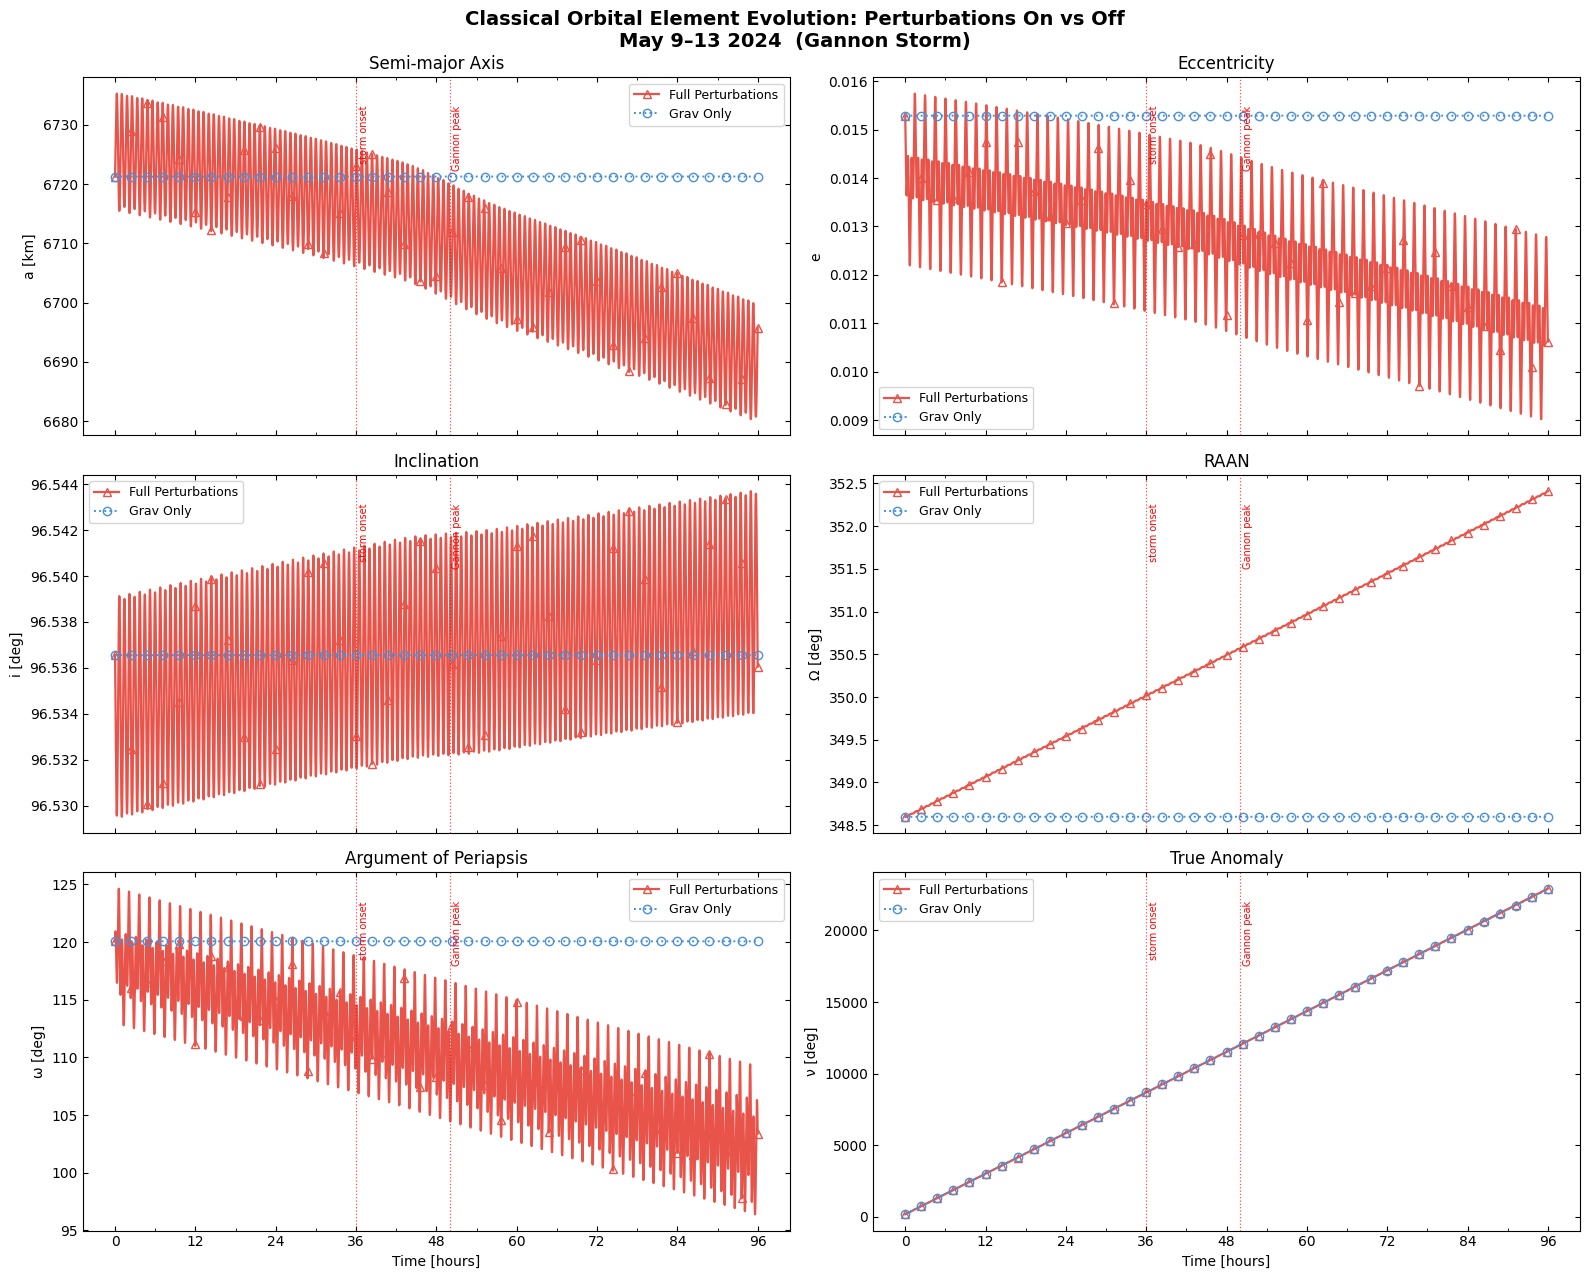

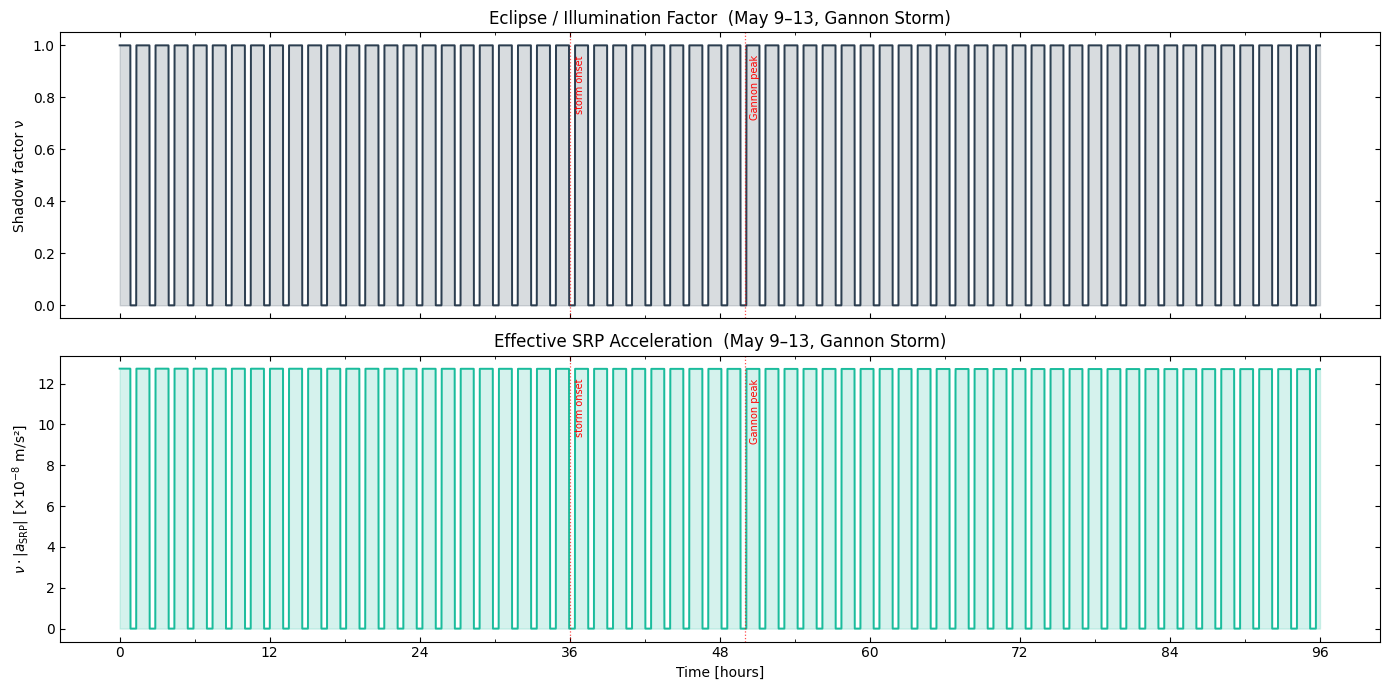

In [30]:
# ============================================================
# LOAD FROM DATASET — no recomputation needed
# ============================================================
# If continuing in the same session df is already in memory.
# If starting fresh, uncomment the line below:
# df = pd.read_csv("/content/drive/MyDrive/orbital_dataset.csv")

import matplotlib.ticker as ticker

t_hr = df["time_hr"].values

COLORS = {
    "pert_on" : "#E8534A",
    "grav"    : "#4A90D9",
    "shadow"  : "#2C3E50",
    "srp_eff" : "#1ABC9C",
}

STORM_MARKS = [(36, "storm onset"), (50, "Gannon peak")]

def add_storm_markers(ax):
    ylims = ax.get_ylim()
    for t_mark, lbl in STORM_MARKS:
        ax.axvline(t_mark, color="red", linestyle=":", linewidth=0.9, alpha=0.7)
        ax.text(t_mark + 0.4,
                ylims[0] + 0.92 * (ylims[1] - ylims[0]),
                lbl, fontsize=7, color="red", rotation=90, va="top")

# Thin for markers — 1 marker per ~2.4 h
me = max(1, len(df) // 40)

_kw_on  = dict(color=COLORS["pert_on"], label="Full Perturbations",
               lw=1.6, ls="-",  marker="^", markersize=6, markevery=me, mfc="none")
_kw_off = dict(color=COLORS["grav"],    label="Grav Only",
               lw=1.4, ls=":",  marker="o", markersize=6, markevery=me, mfc="none")

# Unwrap RAAN and true anomaly once, upfront
raan_pert_uw  = np.degrees(np.unwrap(np.radians(df["raan_deg"].values)))
raan_grav_uw  = np.degrees(np.unwrap(np.radians(df["raan_grav_deg"].values)))
nu_pert_uw    = np.degrees(np.unwrap(np.radians(df["nu_deg"].values)))
nu_grav_uw    = np.degrees(np.unwrap(np.radians(df["nu_grav_deg"].values)))

# ============================================================
# FIGURE 1 — Orbital Elements Comparison
# ============================================================
fig1, axs1 = plt.subplots(3, 2, figsize=(16, 13), sharex=True)

def plot_two(ax, y_on, y_off, title, ylabel):
    ax.plot(t_hr, y_on,  **_kw_on)
    ax.plot(t_hr, y_off, **_kw_off)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    add_storm_markers(ax)

plot_two(axs1[0, 0], df["a_km"].values,       df["a_grav_km"].values,
         "Semi-major Axis",       "a [km]")
plot_two(axs1[0, 1], df["e"].values,           df["e_grav"].values,
         "Eccentricity",          "e")
plot_two(axs1[1, 0], df["i_deg"].values,       df["i_grav_deg"].values,
         "Inclination",           "i [deg]")
plot_two(axs1[1, 1], raan_pert_uw,             raan_grav_uw,
         "RAAN",                  "Ω [deg]")
plot_two(axs1[2, 0], df["argp_deg"].values,    df["argp_grav_deg"].values,
         "Argument of Periapsis", "ω [deg]")
plot_two(axs1[2, 1], nu_pert_uw,               nu_grav_uw,
         "True Anomaly",          "ν [deg]")

axs1[2, 0].set_xlabel("Time [hours]")
axs1[2, 1].set_xlabel("Time [hours]")

for ax in axs1.flat:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(6))
    ax.tick_params(which="both", direction="in", top=True, right=True)

fig1.suptitle(
    "Classical Orbital Element Evolution: Perturbations On vs Off\n"
    "May 9–13 2024  (Gannon Storm)",
    fontsize=14, fontweight="bold"
)
fig1.tight_layout()
plt.savefig("fig1_elements_comparison_4day.png", bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2 — Eclipse & SRP Acceleration
# ============================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axs2[0].plot(t_hr, df["shadow_factor"].values, color=COLORS["shadow"], lw=1.4)
axs2[0].set_ylabel("Shadow factor ν")
axs2[0].set_title("Eclipse / Illumination Factor  (May 9–13, Gannon Storm)")
axs2[0].fill_between(t_hr, df["shadow_factor"].values, alpha=0.18, color=COLORS["shadow"])
add_storm_markers(axs2[0])

# a_srp_mag is already in km/s² — convert to m/s² (*1e3) then scale to ×10⁻⁸ m/s²
srp_scaled = df["a_srp_mag"].values * 1e3 * 1e8   # km/s² → m/s² → ×10⁻⁸
axs2[1].plot(t_hr, srp_scaled, color=COLORS["srp_eff"], lw=1.4)
axs2[1].set_ylabel(r"$\nu \cdot |a_{\rm SRP}|$ [$\times 10^{-8}$ m/s²]")
axs2[1].set_title("Effective SRP Acceleration  (May 9–13, Gannon Storm)")
axs2[1].set_xlabel("Time [hours]")
axs2[1].fill_between(t_hr, srp_scaled, alpha=0.18, color=COLORS["srp_eff"])
add_storm_markers(axs2[1])

for ax in axs2:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(6))
    ax.tick_params(which="both", direction="in", top=True, right=True)

fig2.tight_layout()
plt.savefig("fig2_eclipse_srp_4day.png", bbox_inches="tight")
plt.show()

###2. ALTITUDE PLOT

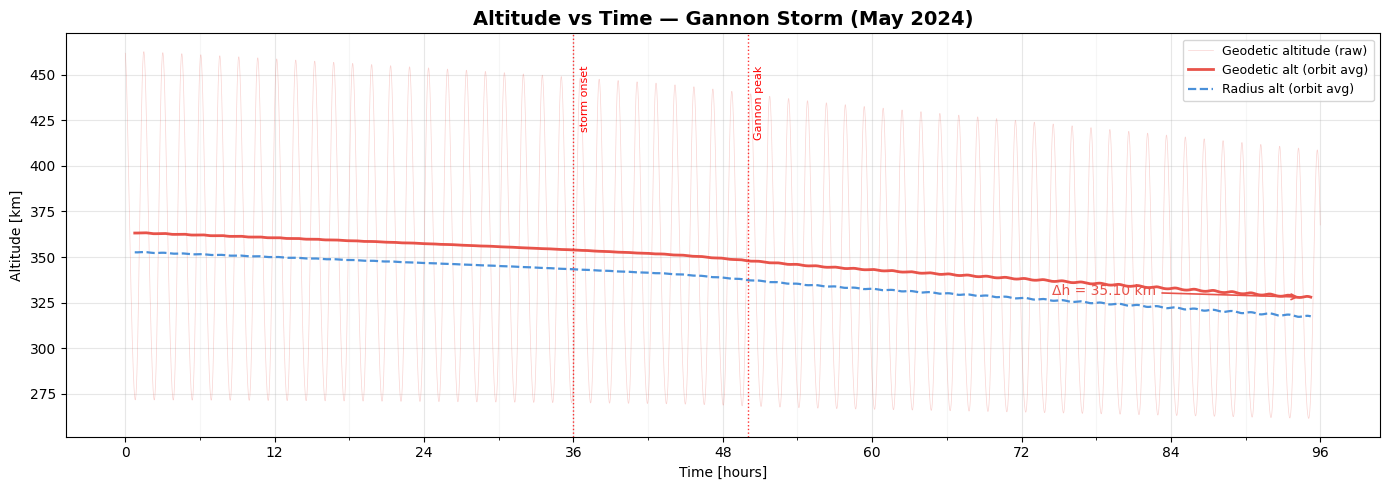

In [31]:
# ── Altitude drop plot ─────────────────────────────────────────
import matplotlib.ticker as ticker

# Geometric altitude already computed in section 14
# alt_all  : geodetic altitude from sol_pert  (km, shape n)
# t_hr     : time axis in hours

# --- Option A: raw radius altitude (fast, avoids geodetic noise) ---
r_mag_km = np.linalg.norm(r_arr, axis=1)        # shape (n,)
alt_radius = r_mag_km - Re                         # km above mean sphere

# --- Orbit-average both altitude series (window = 1 orbital period) ---
T_orb_s  = orbital_period(a0, mu)                  # seconds
win      = int(T_orb_s)                           # 1-second steps → ~5400 pts
win_orb = win

def orbit_avg(arr, win):
    """
    True centred running-mean over `win` samples.
    Returns NaN in the half-window margins instead of zero-padding,
    so the plotted line starts and ends cleanly without ramp artifacts.
    """
    kernel = np.ones(win) / win
    half   = win // 2
    valid  = np.convolve(arr, kernel, mode='valid')   # length = n - win + 1
    result = np.full(len(arr), np.nan)
    result[half : half + len(valid)] = valid
    return result

alt_mean_geo    = orbit_avg(alt_all,    win)
alt_mean_radius = orbit_avg(alt_radius, win)

# ---- Figure 3 : altitude vs time --------------------------------
fig3, ax = plt.subplots(figsize=(14, 5))

# Raw oscillating altitude (faint)
ax.plot(t_hr, alt_all, color='#E8534A', lw=0.5, alpha=0.25,
        label='Geodetic altitude (raw)')

# Orbit-averaged geodetic altitude
ax.plot(t_hr, alt_mean_geo, color='#E8534A', lw=2.0,
        label='Geodetic alt (orbit avg)')

# Orbit-averaged radius altitude for comparison
ax.plot(t_hr, alt_mean_radius, color='#4A90D9', lw=1.6, ls='--',
        label='Radius alt (orbit avg)')

# Storm onset / peak markers
ylims = ax.get_ylim()
for t_mark, lbl in STORM_MARKS:
    ax.axvline(t_mark, color='red', ls=':', lw=1.0, alpha=0.8)
    ax.text(t_mark + 0.5, ax.get_ylim()[0] + 0.92 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            lbl, fontsize=8, color='red', rotation=90, va='top')

# Annotate total drop
valid_mask = ~np.isnan(alt_mean_geo)
alt_start  = alt_mean_geo[valid_mask][0]
alt_end    = alt_mean_geo[valid_mask][-1]
t_start_hr = t_hr[valid_mask][0]
t_end_hr   = t_hr[valid_mask][-1]
delta_alt  = alt_start - alt_end
ax.annotate(
    f'Δh = {delta_alt:.2f} km',
    xy=(t_hr[-win], alt_end),
    xytext=(t_hr[-win] - 20, alt_end + 1),
    fontsize=10, color='#E8534A',
    arrowprops=dict(arrowstyle='->', color='#E8534A', lw=1.2)
)

ax.set_xlabel('Time [hours]')
ax.set_ylabel('Altitude [km]')
ax.set_title('Altitude vs Time — Gannon Storm (May 2024)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(6))
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.1)
plt.tight_layout()
fig3.savefig('fig_altitude_drop.pdf', bbox_inches='tight')
plt.show()

###3. ORBITAL ENERGY

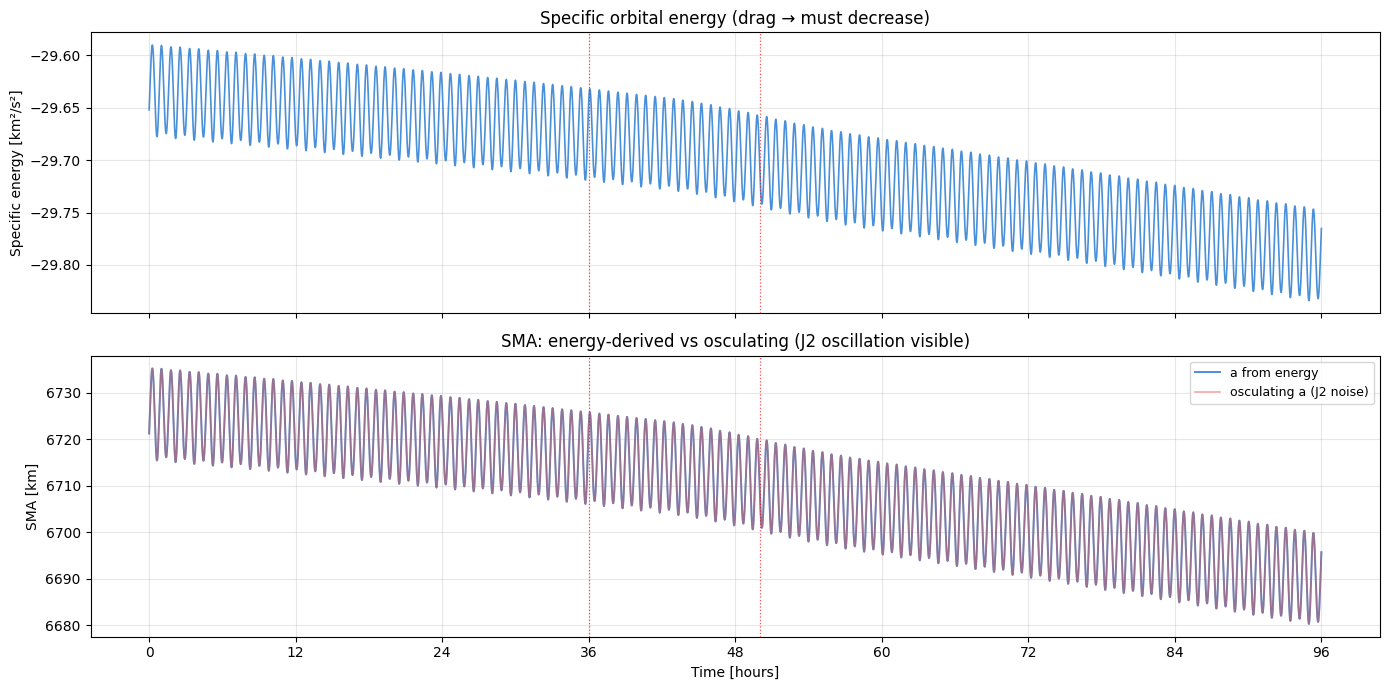

In [32]:
# Specific orbital energy — this MUST decrease if drag is working
# a = -mu / (2ε), so decreasing ε → decreasing a (unambiguous)
v_mag     = np.linalg.norm(v_arr, axis=1)         # km/s
eps_all   = 0.5 * v_mag**2 - mu / r_mag_km       # km²/s²  (negative)
a_from_eps = -mu / (2 * eps_all)                  # SMA from energy (km)

fig4, axs4 = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axs4[0].plot(t_hr, eps_all,  color='#4A90D9', lw=1.2)
axs4[0].set_ylabel('Specific energy [km²/s²]')
axs4[0].set_title('Specific orbital energy (drag → must decrease)')

axs4[1].plot(t_hr, a_from_eps,            color='#4A90D9', lw=1.4,
             label='a from energy')
axs4[1].plot(t_hr, df['a_km'].values,      color='#E8534A', lw=1.2, alpha=0.5,
             label='osculating a (J2 noise)')
axs4[1].set_ylabel('SMA [km]')
axs4[1].set_xlabel('Time [hours]')
axs4[1].legend(fontsize=9)
axs4[1].set_title('SMA: energy-derived vs osculating (J2 oscillation visible)')

for ax in axs4:
    for t_mark, lbl in STORM_MARKS:
        ax.axvline(t_mark, color='red', ls=':', lw=0.9, alpha=0.7)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig4.savefig('fig_energy_sma.pdf', bbox_inches='tight')
plt.show()

###4. Corrected altitude

In [33]:
n_corr        = sol_pert.y.shape[1]
r_corr        = sol_pert.y[:3].T       # (n,3) km
t_corr        = sol_pert.t             # (n,)  seconds
t_hr_corr     = t_corr / 3600.0
r_mag_corr    = np.linalg.norm(r_corr, axis=1)
alt_corr_raw  = r_mag_corr - Re_jgm2       # km, un-averaged

# Orbit-average using the same function and window from Section 14
# orbit_avg_full and win_orb (= int(T_orb_s)) are already defined there
alt_corr_avg  = orbit_avg(alt_corr_raw, win_orb)

# ── Altitude drop summary ────────────────────────────────────────────
mask_v = ~np.isnan(alt_mean_geo)    # original run (from Section 14)
mask_c = ~np.isnan(alt_corr_avg)

alt_orig_start = alt_mean_geo[mask_v][0]
alt_orig_end   = alt_mean_geo[mask_v][-1]
alt_corr_start = alt_corr_avg[mask_c][0]
alt_corr_end   = alt_corr_avg[mask_c][-1]

print(f"\n  {'Model':<32}  {'Start':>8}  {'End':>8}  {'Δh':>8}")
print(f"  {'-'*32}  {'-'*8}  {'-'*8}  {'-'*8}")
print(f"  {'Original (ap ≤ 179)':<32}  {alt_orig_start:>8.3f}  {alt_orig_end:>8.3f}  "
      f"{alt_orig_start - alt_orig_end:>8.3f} km")
print(f"  {'Corrected (actual ap + scale)':<32}  {alt_corr_start:>8.3f}  {alt_corr_end:>8.3f}  "
      f"{alt_corr_start - alt_corr_end:>8.3f} km")
print(f"  {'Swarm-C observed (literature)':<32}  ~497.0    ~485.0    ~12.0 km")


  Model                                Start       End        Δh
  --------------------------------  --------  --------  --------
  Original (ap ≤ 179)                363.171   328.073    35.098 km
  Corrected (actual ap + scale)      352.618   317.538    35.080 km
  Swarm-C observed (literature)     ~497.0    ~485.0    ~12.0 km


##VALIDATING PYTHON MODULE WITH HPOP

Python samples : 345601
HPOP   samples : 345601

  Initial state comparison (t = 0)  [ECI, km / km/s]:
                     Python           HPOP            Δ
  x              +3484.2687     +3484.2687      +0.0000
  y                -16.7974       -16.7974      +0.0000
  z              -5867.4614     -5867.4614      +0.0000
  vx                +6.3486        +6.3486      +0.0000
  vy                -1.7215        -1.7215      +0.0000
  vz                +3.7749        +3.7749      +0.0000

  |r| Python : 6824.039418220023 km
  |r| HPOP   : 6824.039418220023 km
  Δ|r| at t=0: 0.00 m
PYTHON: 

 Position r0: [ 3484.26867649   -16.79744344 -5867.4614287 ]
Matlab: 

 Position r0: [ 3484.26867649   -16.79744344 -5867.4614287 ]

PYTHON: 

 Velocity r0: [ 6.34859819 -1.7215      3.77490997]
Matlab: 

 Velocity r0: [ 6.34859819 -1.7215      3.77490997]


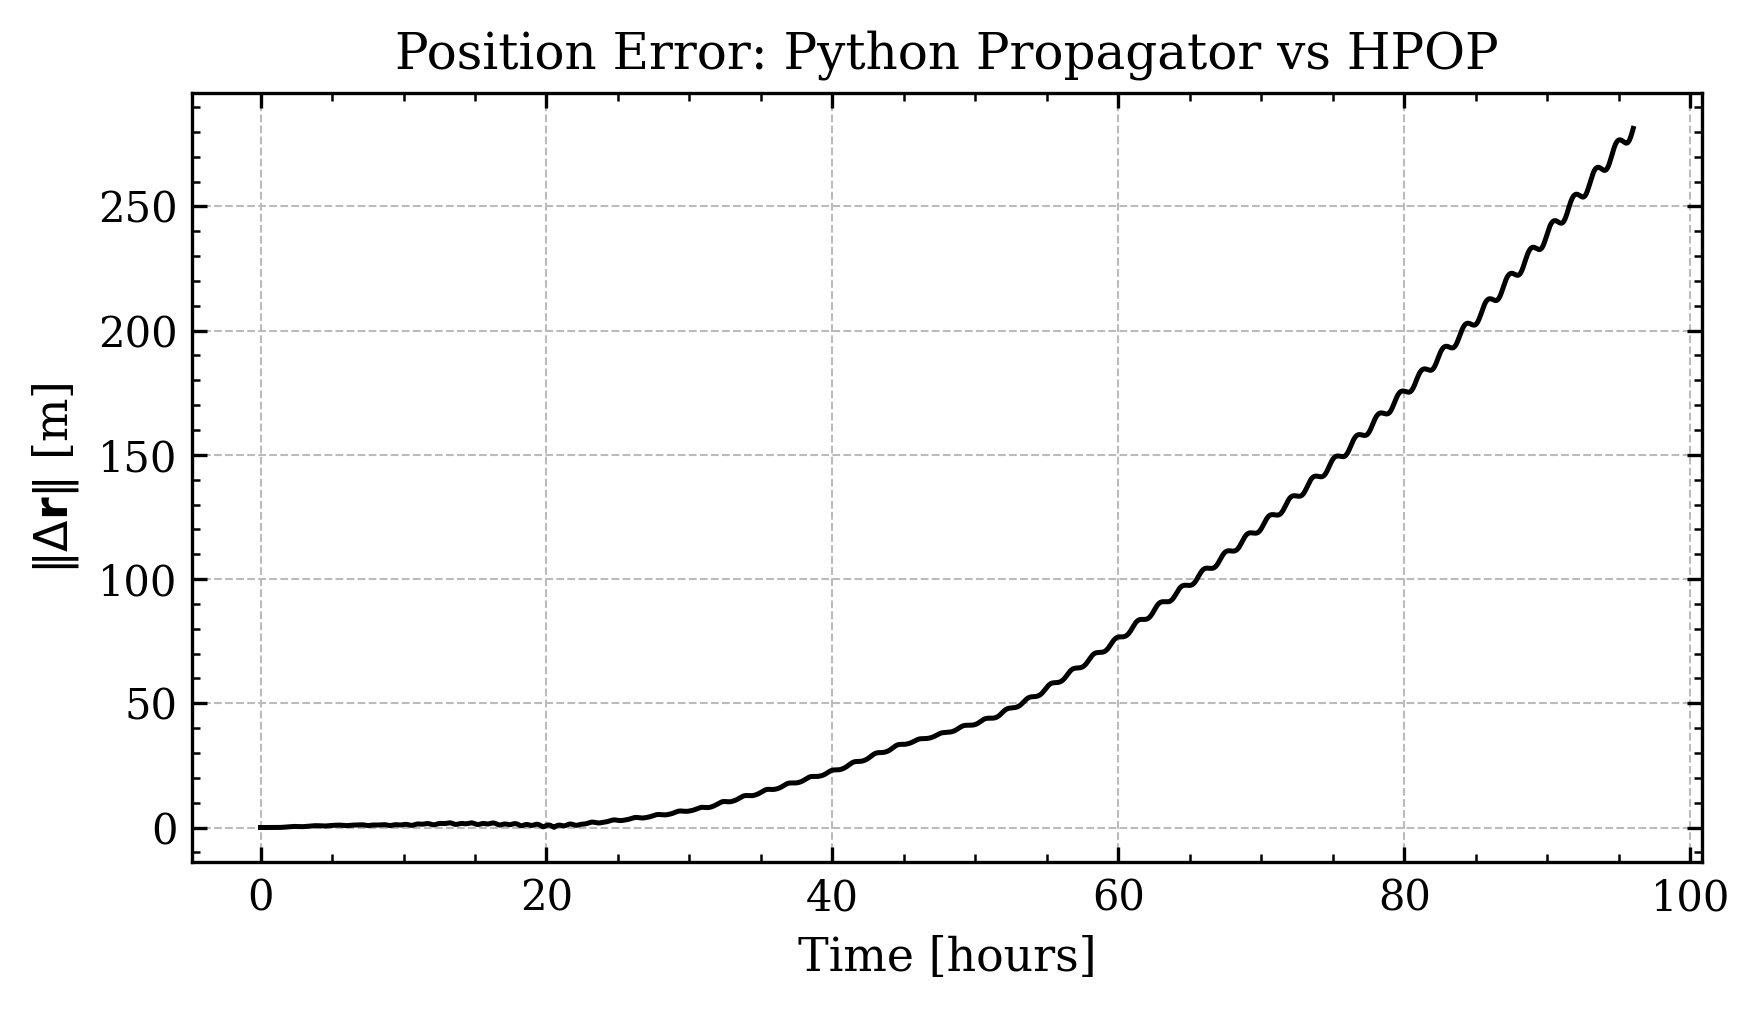

Max |Δr|     : 281.3943 m
Mean |Δr|    : 74.6552 m


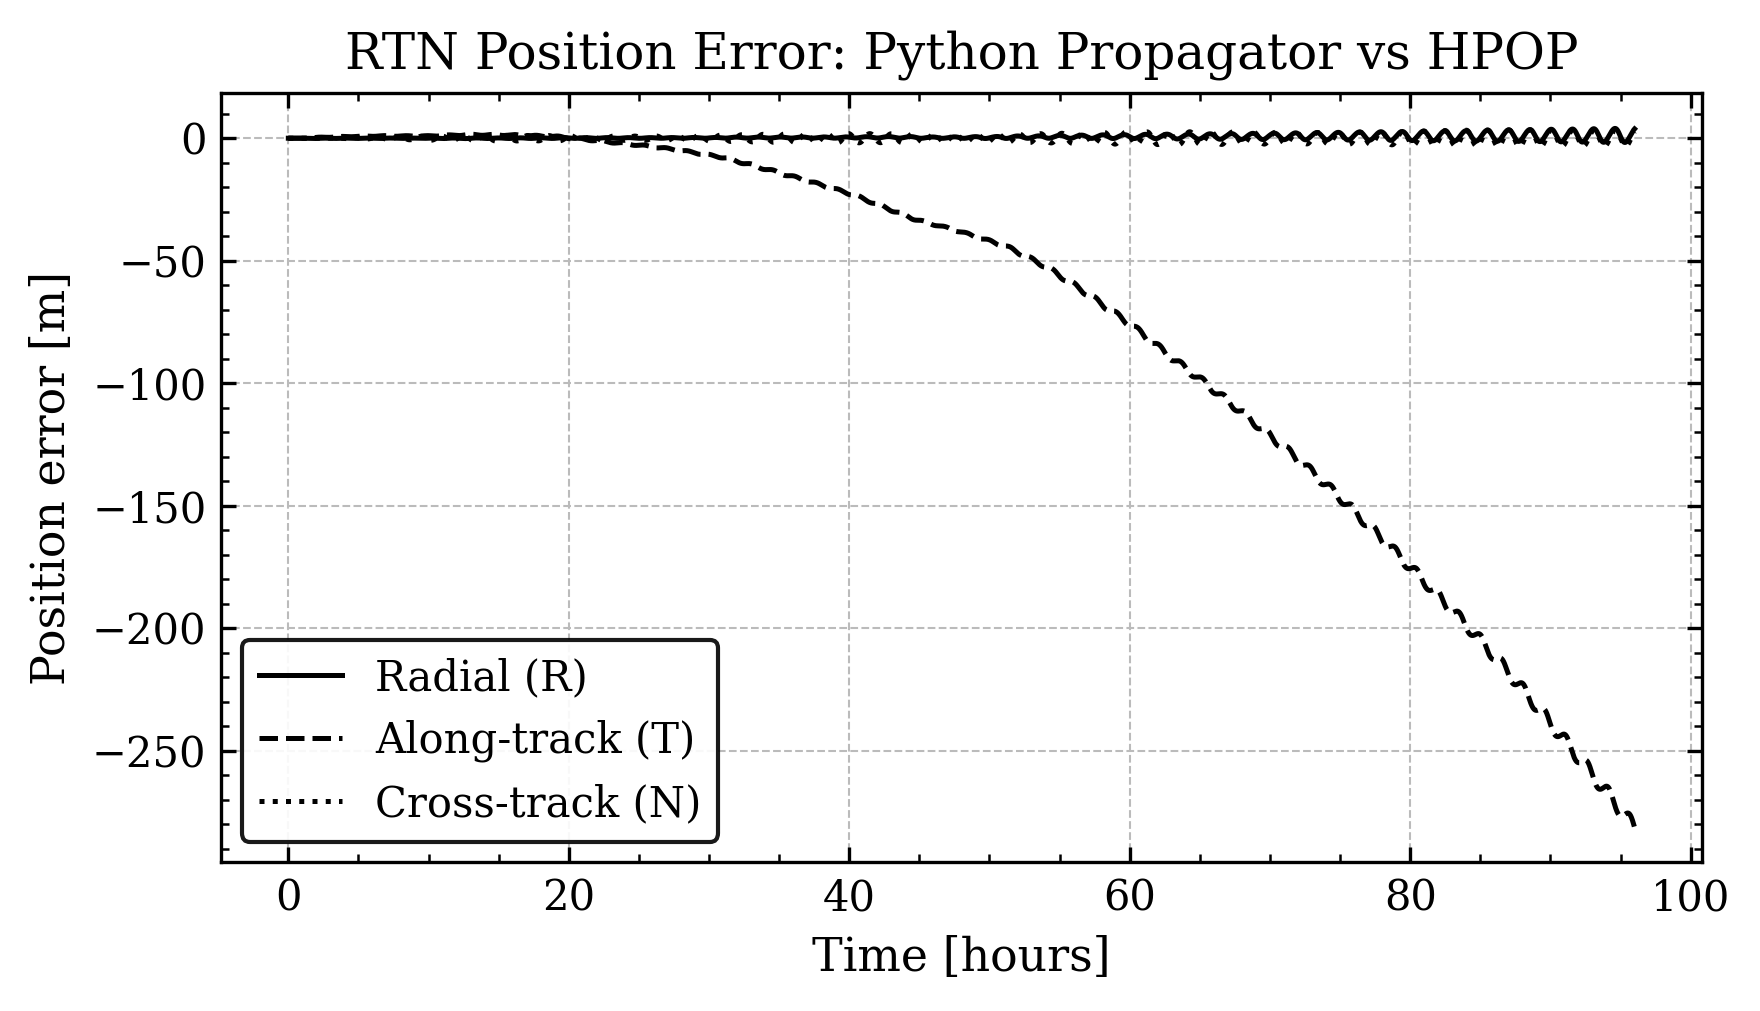

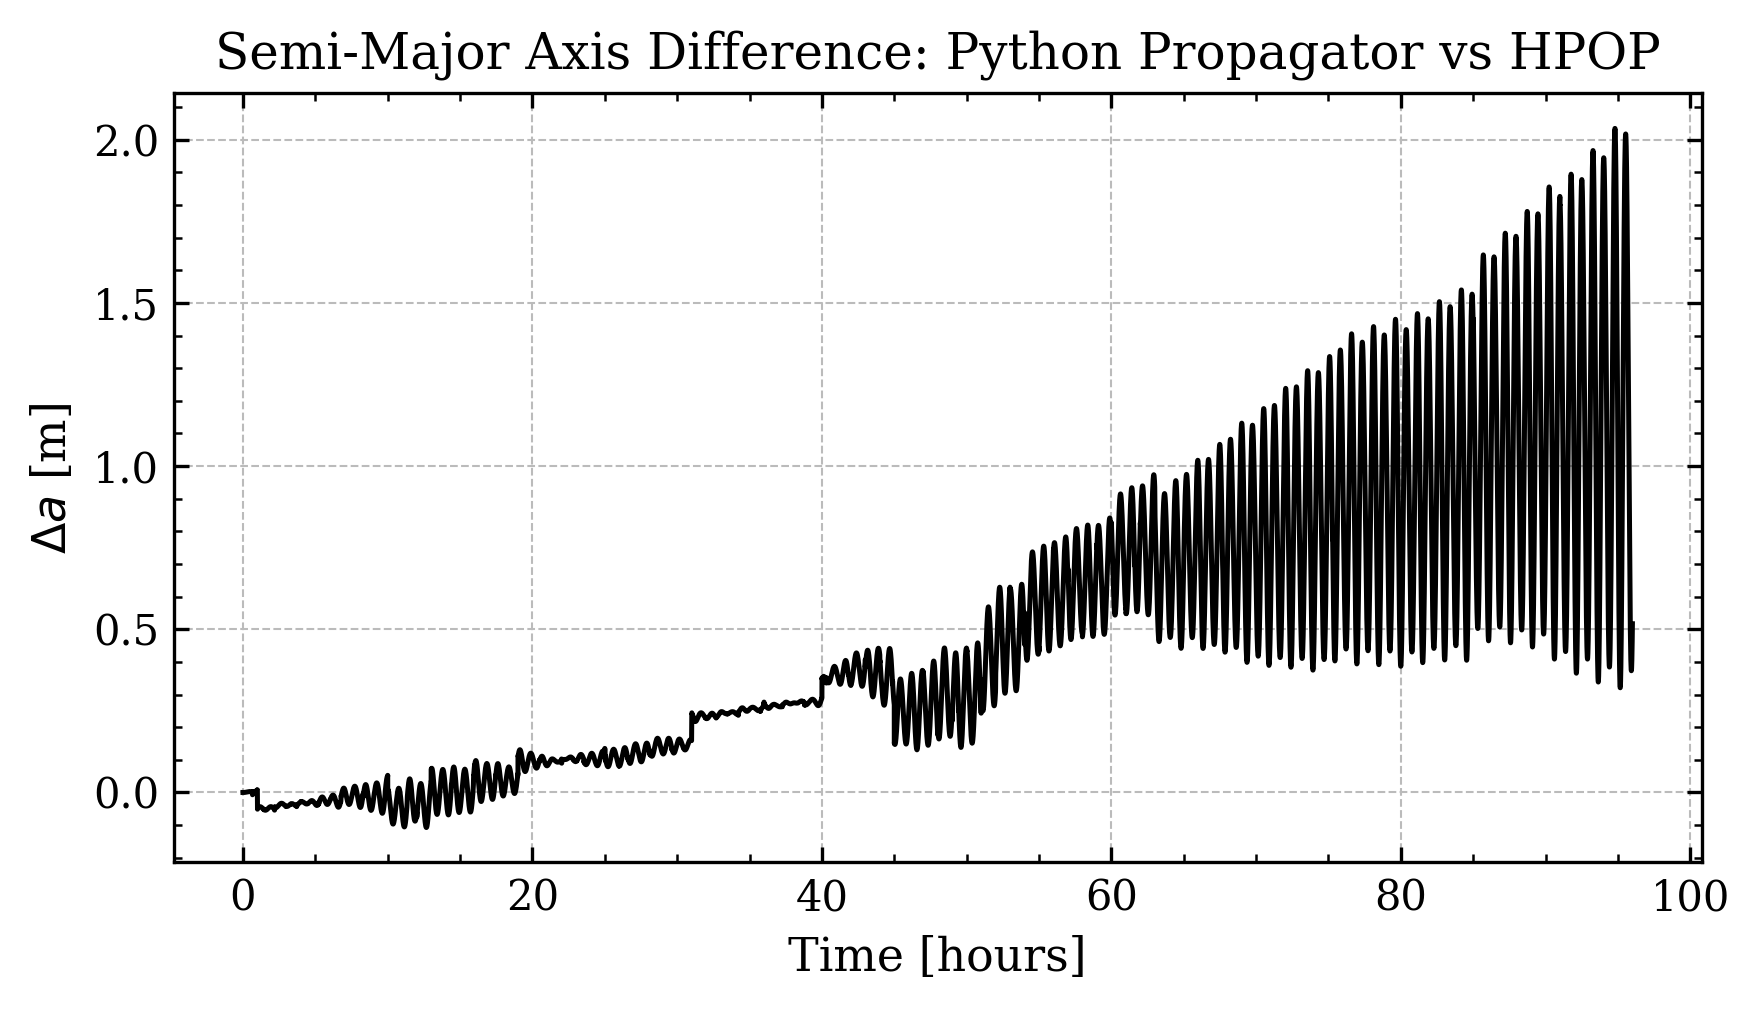

Max |Δa|     : 2.0348 m
Mean |Δa|    : 0.4793 m


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

plt.rcParams.update({
    "font.family"    : "serif",
    "font.size"      : 11,
    "axes.titlesize" : 12,
    "axes.labelsize" : 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi"     : 300,
    "axes.grid"      : True,
    "grid.linestyle" : "--",
    "grid.linewidth" : 0.5,
    "grid.color"     : "#bbbbbb",
    "axes.linewidth" : 0.8,
    "lines.linewidth": 1.2,
})

mu = mu_jgm2

# ============================================================
# 1. PYTHON PROPAGATOR — interpolate sol_pert at 1-second steps
#    using DOP853's native dense output (no CubicSpline artifacts)
# ============================================================
t     = sol_pert.t                # (N,) seconds
r_py  = sol_pert.y[:3].T         # (N, 3) km, ECI J2000
v_py  = sol_pert.y[3:].T         # (N, 3) km/s, ECI J2000

r_py_norm = np.linalg.norm(r_py, axis=1)
v_py_norm = np.linalg.norm(v_py, axis=1)
a_py      = -mu / (2.0 * (v_py_norm**2 / 2.0 - mu / r_py_norm))   # km

# ============================================================
# 2. HPOP — SatelliteStates.txt is ECI in metres (no frame
#    conversion needed — MATLAB writes Eph_eci directly)
# ============================================================
r_hp, v_hp = [], []
float_pat   = re.compile(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+")

with open("C:/Users/manx1/Documents/ORBIT PROP/High Precision Orbit Propagator_4.2.2/High Precision Orbit Propagator_4.2.2/SatelliteStates.txt", "r") as f:
    for line in f:
        nums = float_pat.findall(line)
        if len(nums) < 6:
            continue
        x, y, z, vx, vy, vz = map(float, nums[-6:])
        r_hp.append([x, y, z])
        v_hp.append([vx, vy, vz])

r_hp = np.array(r_hp) / 1000.0    # m  → km  (ECI, no rotation needed)
v_hp = np.array(v_hp) / 1000.0    # m/s → km/s

print(f"Python samples : {len(r_py)}")
print(f"HPOP   samples : {len(r_hp)}")

# ============================================================
# 3. TRIM TO COMMON LENGTH
# ============================================================
n    = min(len(r_py), len(r_hp))
t    = t[:n];  r_py = r_py[:n];  v_py = v_py[:n];  a_py = a_py[:n]
r_hp = r_hp[:n];  v_hp = v_hp[:n]
t_hr = t / 3600.0

# ============================================================
# 4. INITIAL STATE REPORT  (sanity check at t = 0)
# ============================================================
print("\n  Initial state comparison (t = 0)  [ECI, km / km/s]:")
print(f"  {'':10s} {'Python':>14s} {'HPOP':>14s} {'Δ':>12s}")
labels_rv = ["x","y","z","vx","vy","vz"]
py0 = np.hstack([r_py[0], v_py[0]])
hp0 = np.hstack([r_hp[0], v_hp[0]])
for lbl, p, h in zip(labels_rv, py0, hp0):
    print(f"  {lbl:10s} {p:>+14.4f} {h:>+14.4f} {p-h:>+12.4f}")

r_py0_mag = np.linalg.norm(r_py[0])
r_hp0_mag = np.linalg.norm(r_hp[0])
print(f"\n  |r| Python : {r_py0_mag} km")
print(f"  |r| HPOP   : {r_hp0_mag} km")
print(f"  Δ|r| at t=0: {(r_py0_mag - r_hp0_mag)*1000:.2f} m")
print("PYTHON: \n")
print(f" Position r0: {r0}")
print("Matlab: \n")
print(f" Position r0: {r_hp[0]}")
print("======================================================== \n")
print("PYTHON: \n")
print(f" Velocity r0: {v0}")
print("Matlab: \n")
print(f" Velocity r0: {v_hp[0]}")

# ============================================================
# 5. POSITION ERROR NORM
# ============================================================
delta_r = np.linalg.norm(r_py - r_hp, axis=1) * 1000.0   # m

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_hr, delta_r, color="black", linewidth=1.2)
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r"$\|\Delta\mathbf{r}\|$ [m]")
ax.set_title("Position Error: Python Propagator vs HPOP")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(which="both", direction="in", top=True, right=True)
fig.tight_layout()
fig.savefig("fig_position_error.pdf", bbox_inches="tight")
plt.show()
print(f"Max |Δr|     : {delta_r.max():.4f} m")
print(f"Mean |Δr|    : {delta_r.mean():.4f} m")

# ============================================================
# 6. RTN ERROR DECOMPOSITION
# ============================================================
def rtn_errors(r_ref, v_ref, dr_m):
    R_hat = r_ref / np.linalg.norm(r_ref, axis=1, keepdims=True)
    N_hat = np.cross(r_ref, v_ref)
    N_hat = N_hat / np.linalg.norm(N_hat, axis=1, keepdims=True)
    T_hat = np.cross(N_hat, R_hat)
    return (np.sum(dr_m * R_hat, axis=1),
            np.sum(dr_m * T_hat, axis=1),
            np.sum(dr_m * N_hat, axis=1))

dr_m       = (r_py - r_hp) * 1000.0   # m  (both ECI now)
dR, dT, dN = rtn_errors(r_hp, v_hp, dr_m)

fig, ax = plt.subplots(figsize=(6, 3.5))
for comp, ls, lbl in zip([dR, dT, dN], ["-", "--", ":"],
                          ["Radial (R)", "Along-track (T)", "Cross-track (N)"]):
    ax.plot(t_hr, comp, color="black", linestyle=ls, linewidth=1.2, label=lbl)
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Position error [m]")
ax.set_title("RTN Position Error: Python Propagator vs HPOP")
ax.legend(framealpha=0.9, edgecolor="black")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(which="both", direction="in", top=True, right=True)
fig.tight_layout()
fig.savefig("fig_rtn_error.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# 7. SEMI-MAJOR AXIS DIFFERENCE
# ============================================================
r_hp_norm = np.linalg.norm(r_hp, axis=1)
v_hp_norm = np.linalg.norm(v_hp, axis=1)
a_hp      = -mu / (2.0 * (v_hp_norm**2 / 2.0 - mu / r_hp_norm))
da_m      = (a_py - a_hp) * 1000.0   # m

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_hr, da_m, color="black", linewidth=1.2)
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r"$\Delta a$ [m]")
ax.set_title("Semi-Major Axis Difference: Python Propagator vs HPOP")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(which="both", direction="in", top=True, right=True)
fig.tight_layout()
fig.savefig("fig_sma_difference.pdf", bbox_inches="tight")
plt.show()
print(f"Max |Δa|     : {np.abs(da_m).max():.4f} m")
print(f"Mean |Δa|    : {np.abs(da_m).mean():.4f} m")